In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import pickle
import networkx as nx

In [34]:
files = [
    "results_w1_wio.pkl",
    "results_w2_wio.pkl",
    "results_w3_wio.pkl",
]

datos = []
for f in files:
    with open(f, "rb") as file:
        data = pickle.load(file)
    datos.append(data)

groups_df = pd.read_csv("basa_groups.csv")
species_to_community = dict(zip(groups_df["Taxa"], groups_df["Community"]))

# reciprocidad

ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (4).

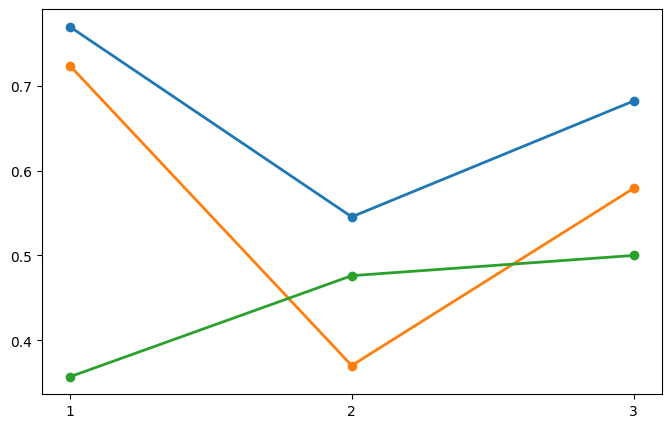

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# --- función para construir grafo dirigido ---
def construir_grafo_dir(mat_sig, especies, species_to_community, tipo="all"):
    G = nx.DiGraph()
    
    for sp in especies:
        if sp in species_to_community:
            G.add_node(species_to_community[sp])
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = species_to_community[sp_i]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            if i == j:
                continue
            
            cj = species_to_community[sp_j]
            val = mat_sig[i][j]
            
            if val == 0:
                continue
            
            # filtrar según tipo
            if tipo == "pos" and val != 1:
                continue
            if tipo == "neg" and val != -1:
                continue
            
            # ignoramos signo en la estructura
            G.add_edge(ci, cj)
    
    return G


# --- calcular reciprocidad ---
rec_all = []
rec_pos = []
rec_neg = []

for data in datos:
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    G_all = construir_grafo_dir(mat_sig, especies, species_to_community, "all")
    G_pos = construir_grafo_dir(mat_sig, especies, species_to_community, "pos")
    G_neg = construir_grafo_dir(mat_sig, especies, species_to_community, "neg")
    
    rec_all.append(nx.reciprocity(G_all))
    rec_pos.append(nx.reciprocity(G_pos))
    rec_neg.append(nx.reciprocity(G_neg))


# --- plot ---
x = np.arange(1, len(rec_all) + 1)

plt.figure(figsize=(8,5))

plt.plot(x, rec_all, marker='o', linewidth=2, label='Dirigida (sin signo)')
plt.plot(x, rec_pos, marker='o', linewidth=2, label='Solo positivas')
plt.plot(x, rec_neg, marker='o', linewidth=2, label='Solo negativas')

plt.xticks(x, ["w1", "w2", "w3", "w4"])
plt.xlabel("Ventana temporal")
plt.ylabel("Reciprocidad")
plt.title("Reciprocidad en redes por comunidades")

plt.legend()
plt.grid(True)
plt.ylim(0,1)

plt.tight_layout()
plt.show()

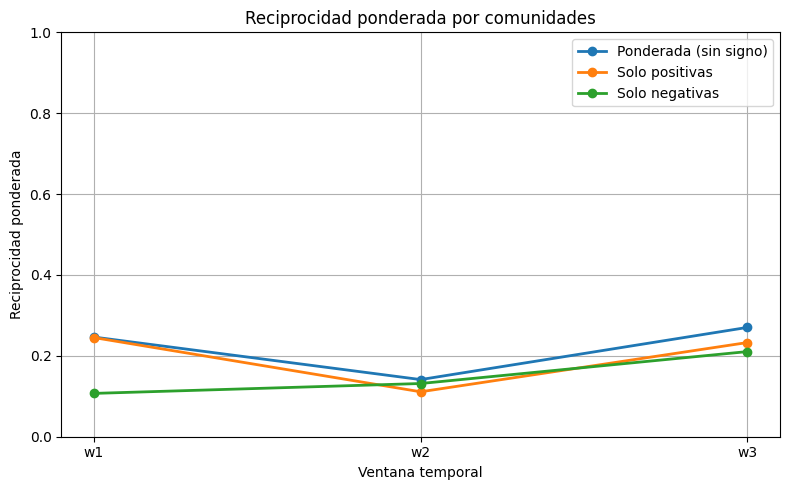

In [12]:
def construir_matriz_pesos(mat_sig, especies, species_to_community, tipo="all"):
    comunidades = sorted(set(
        species_to_community[sp] for sp in especies if sp in species_to_community
    ))
    
    idx = {c: i for i, c in enumerate(comunidades)}
    n = len(comunidades)
    
    W = np.zeros((n, n))
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = idx[species_to_community[sp_i]]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            if i == j:
                continue
            
            cj = idx[species_to_community[sp_j]]
            val = mat_sig[i][j]
            
            if val == 0:
                continue
            
            if tipo == "pos" and val != 1:
                continue
            if tipo == "neg" and val != -1:
                continue
            
            W[ci, cj] += 1  # acumulamos peso
    
    return W, comunidades

def reciprocidad_ponderada(W):
    num = 0.0
    den = np.sum(W)
    
    if den == 0:
        return np.nan
    
    n = W.shape[0]
    
    for i in range(n):
        for j in range(i+1, n):
            num += min(W[i, j], W[j, i])
    
    return num / den

rec_w_all = []
rec_w_pos = []
rec_w_neg = []

for data in datos:
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    W_all, _ = construir_matriz_pesos(mat_sig, especies, species_to_community, "all")
    W_pos, _ = construir_matriz_pesos(mat_sig, especies, species_to_community, "pos")
    W_neg, _ = construir_matriz_pesos(mat_sig, especies, species_to_community, "neg")
    
    rec_w_all.append(reciprocidad_ponderada(W_all))
    rec_w_pos.append(reciprocidad_ponderada(W_pos))
    rec_w_neg.append(reciprocidad_ponderada(W_neg))

x = np.arange(1, len(rec_w_all) + 1)

plt.figure(figsize=(8,5))

plt.plot(x, rec_w_all, marker='o', linewidth=2, label='Ponderada (sin signo)')
plt.plot(x, rec_w_pos, marker='o', linewidth=2, label='Solo positivas')
plt.plot(x, rec_w_neg, marker='o', linewidth=2, label='Solo negativas')

plt.xticks(x, ["w1", "w2", "w3"])
plt.xlabel("Ventana temporal")
plt.ylabel("Reciprocidad ponderada")
plt.title("Reciprocidad ponderada por comunidades")

plt.legend()
plt.grid(True)
plt.ylim(0,1)

plt.tight_layout()
plt.show()

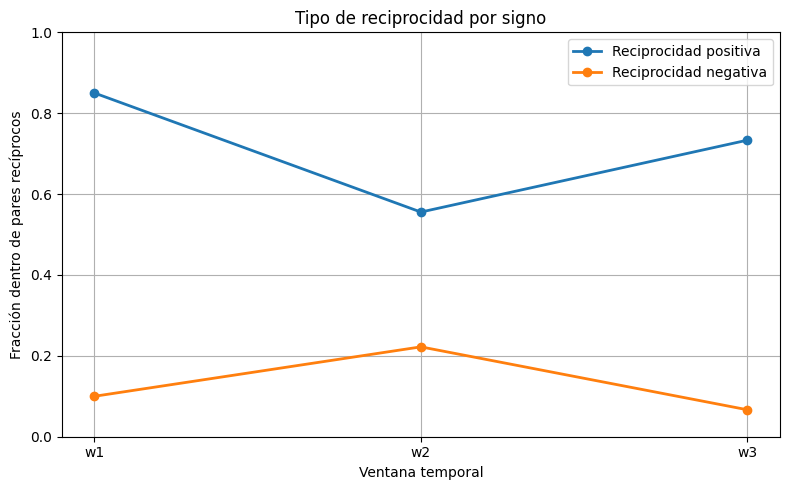

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- construir presencia de signos por comunidad ---
def construir_presencia_signo(mat_sig, especies, species_to_community):
    comunidades = sorted(set(
        species_to_community[sp] for sp in especies if sp in species_to_community
    ))
    
    idx = {c: i for i, c in enumerate(comunidades)}
    n = len(comunidades)
    
    pos = np.zeros((n, n), dtype=int)
    neg = np.zeros((n, n), dtype=int)
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = idx[species_to_community[sp_i]]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            if i == j:
                continue
            
            cj = idx[species_to_community[sp_j]]
            val = mat_sig[i][j]
            
            if val == 1:
                pos[ci, cj] = 1
            elif val == -1:
                neg[ci, cj] = 1
    
    return pos, neg


# --- calcular fracciones ---
def reciprocidad_por_signo(pos, neg):
    n = pos.shape[0]
    
    total_rec = 0
    rec_pos = 0
    rec_neg = 0
    
    for i in range(n):
        for j in range(i+1, n):
            
            # reciprocidad sin signo
            if (pos[i,j] or neg[i,j]) and (pos[j,i] or neg[j,i]):
                
                total_rec += 1
                
                # positiva
                if pos[i,j] and pos[j,i]:
                    rec_pos += 1
                
                # negativa
                elif neg[i,j] and neg[j,i]:
                    rec_neg += 1
    
    if total_rec == 0:
        return np.nan, np.nan
    
    return rec_pos / total_rec, rec_neg / total_rec


# --- aplicar a tus redes ---
frac_pos = []
frac_neg = []

for data in datos:
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    pos, neg = construir_presencia_signo(mat_sig, especies, species_to_community)
    
    fpos, fneg = reciprocidad_por_signo(pos, neg)
    
    frac_pos.append(fpos)
    frac_neg.append(fneg)


# --- plot ---
x = np.arange(1, len(frac_pos) + 1)

plt.figure(figsize=(8,5))

plt.plot(x, frac_pos, marker='o', linewidth=2, label='Reciprocidad positiva')
plt.plot(x, frac_neg, marker='o', linewidth=2, label='Reciprocidad negativa')

plt.xticks(x, ["w1", "w2", "w3"])
plt.xlabel("Ventana temporal")
plt.ylabel("Fracción dentro de pares recíprocos")
plt.title("Tipo de reciprocidad por signo")

plt.ylim(0,1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
def clasificar_pares(mat_sig, especies, species_to_community):
    pos, neg = construir_presencia_signo(mat_sig, especies, species_to_community)
    
    comunidades = sorted(set(
        species_to_community[sp] for sp in especies if sp in species_to_community
    ))
    
    n = len(comunidades)
    
    pares_pos = []
    pares_neg = []
    pares_mix = []
    
    for i in range(n):
        for j in range(i+1, n):
            
            # reciprocidad sin signo
            if (pos[i,j] or neg[i,j]) and (pos[j,i] or neg[j,i]):
                
                ci = comunidades[i]
                cj = comunidades[j]
                
                if pos[i,j] and pos[j,i]:
                    pares_pos.append((ci, cj))
                
                elif neg[i,j] and neg[j,i]:
                    pares_neg.append((ci, cj))
                
                else:
                    pares_mix.append((ci, cj))
    
    return pares_pos, pares_neg, pares_mix

for t, data in enumerate(datos):
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    pares_pos, pares_neg, pares_mix = clasificar_pares(
        mat_sig, especies, species_to_community
    )
    
    print(f"\nRed {t+1}:")
    print(f"  Positivos ({len(pares_pos)}): {pares_pos}")
    print(f"  Negativos ({len(pares_neg)}): {pares_neg}")
    print(f"  Mixtos    ({len(pares_mix)}): {pares_mix}")

import matplotlib.pyplot as plt

def matriz_tipo_pares(mat_sig, especies, species_to_community):
    pos, neg = construir_presencia_signo(mat_sig, especies, species_to_community)
    
    comunidades = sorted(set(
        species_to_community[sp] for sp in especies if sp in species_to_community
    ))
    
    n = len(comunidades)
    M = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            
            if (pos[i,j] or neg[i,j]) and (pos[j,i] or neg[j,i]):
                
                if pos[i,j] and pos[j,i]:
                    M[i,j] = M[j,i] = 1   # positivo
                elif neg[i,j] and neg[j,i]:
                    M[i,j] = M[j,i] = -1  # negativo
                else:
                    M[i,j] = M[j,i] = 0.5   # mixto
    
    return M, comunidades


# # ejemplo con una red
# M, comunidades = matriz_tipo_pares(
#     datos[2]["matriz_significancia"],
#     datos[2]["especies"],
#     species_to_community
# )

# plt.imshow(M, cmap=plt.cm.RdYlGn)

# plt.colorbar(label="1=positivo, -1=negativo, 0=mixto", ticks=[-1, 0, 1] , cmap=plt.cm.RdYlGn)
# plt.xticks(range(len(comunidades)), comunidades, rotation=90)
# plt.yticks(range(len(comunidades)), comunidades)
# plt.title("Tipo de reciprocidad entre comunidades (w3)")
# plt.tight_layout()
# plt.show()


Red 1:
  Positivos (17): [('grassland', 'mediterranean'), ('grassland', 'pastureland'), ('grassland', 'pinewoods'), ('grassland', 'riverine community'), ('grassland', 'shrubland'), ('grassland', 'temperate forest'), ('mediterranean', 'pastureland'), ('mediterranean', 'pinewoods'), ('mediterranean', 'riverine community'), ('mediterranean', 'temperate forest'), ('pastureland', 'pinewoods'), ('pastureland', 'shrubland'), ('pastureland', 'temperate forest'), ('pinewoods', 'riverine community'), ('pinewoods', 'temperate forest'), ('riverine community', 'shrubland'), ('riverine community', 'temperate forest')]
  Negativos (2): [('mediterranean', 'shrubland'), ('pinewoods', 'shrubland')]
  Mixtos    (1): [('pastureland', 'riverine community')]

Red 2:
  Positivos (5): [('grassland', 'pastureland'), ('grassland', 'riverine community'), ('grassland', 'shrubland'), ('pastureland', 'pinewoods'), ('pinewoods', 'riverine community')]
  Negativos (2): [('grassland', 'pinewoods'), ('pastureland', 'r

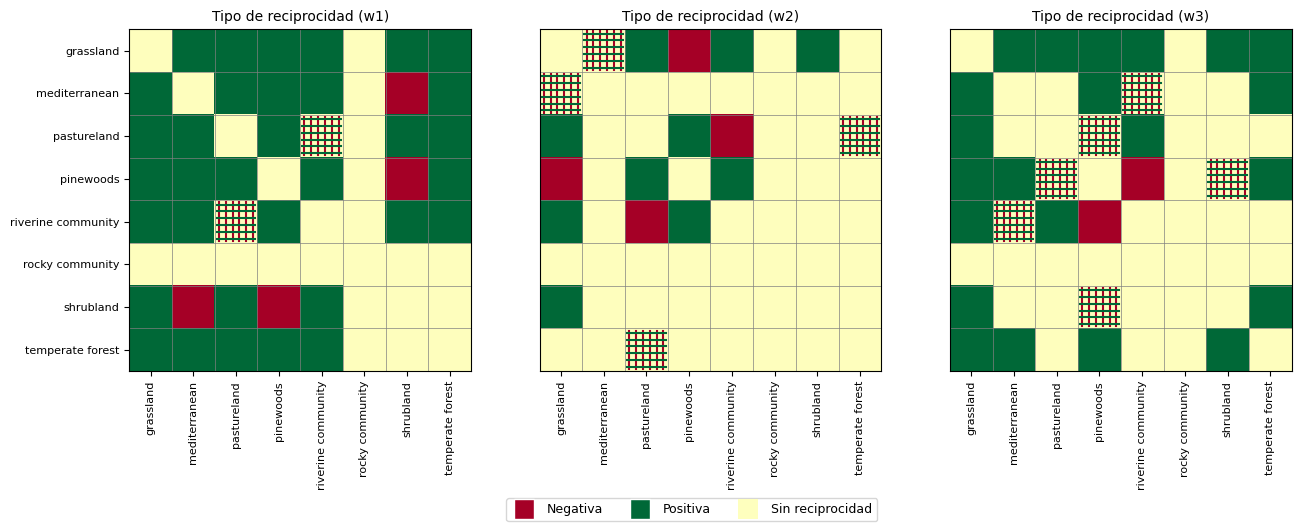

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# =========================
# MATRICES (tu código original)
# =========================
M1, comunidades = matriz_tipo_pares(
    datos[0]["matriz_significancia"],
    datos[0]["especies"],
    species_to_community
)

M2, _ = matriz_tipo_pares(
    datos[1]["matriz_significancia"],
    datos[1]["especies"],
    species_to_community
)

M3, _ = matriz_tipo_pares(
    datos[2]["matriz_significancia"],
    datos[2]["especies"],
    species_to_community
)

matrices = [M1, M2, M3]
titulos = ["w1", "w2", "w3"]

# =========================
# COLORES DISCRETOS
# =========================
base = plt.cm.RdYlGn

red = base(0.0)  
red_exacto = base(0.0)    # rojo para -1
green = base(1.0) 
green_exacto = base(1.0)    # verde para 1
yellow = base(0.5)   # amarillo para 0 y -0.5

colores = [
    red,        # -1
    yellow,     # -0.5
    yellow,     # 0
    yellow,     # 0.5 (base amarilla)
    green       # 1
]

cmap = mcolors.ListedColormap(colores)

bounds = [-1.5, -0.75, -0.25, 0.25, 0.75, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

valores = [-1, -0.5, 0, 0.5, 1]

# =========================
# FIGURA
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, ax in enumerate(axes):
    
    M = matrices[i]

    # Mostrar la matriz con colores base
    im = ax.imshow(M, cmap=cmap, norm=norm)

    # =========================
    # AÑADIR HATCH PARA 0.5 (versión corregida)
    # =========================
    # Opción 2: Patrón de puntos
    # Dentro del bucle, reemplaza la sección del hatch con:
    
    # Dentro del bucle, reemplaza la sección del hatch con:
    mask_05 = (M == 0.5)
    y, x = np.where(mask_05)

    for xi, yi in zip(x, y):
        # Rayitas rojas (verticales)
        for offset in np.linspace(-0.4, 0.4, 6):  # 7 líneas verticales rojas
            ax.plot([xi + offset, xi + offset], 
                    [yi - 0.45, yi + 0.45], 
                    color=red_exacto, linewidth=1.5, alpha=1)
        
        # Rayitas verdes (horizontales)
        for offset in np.linspace(-0.4, 0.4, 6):  # 7 líneas horizontales verdes
            ax.plot([xi - 0.45, xi + 0.45], 
                    [yi + offset, yi + offset], 
                    color=green_exacto, linewidth=1.5, alpha=1)
    # Alternativa más simple: usar texturizado con patches
    # Esta opción es más elegante pero requiere más código

    # =========================
    # ETIQUETAS
    # =========================
    ax.set_xticks(range(len(comunidades)))
    ax.set_xticklabels(comunidades, rotation=90, fontsize=8)

    ax.set_yticks(range(len(comunidades)))
    ax.set_yticklabels(comunidades, fontsize=8)

    ax.set_title(f"Tipo de reciprocidad ({titulos[i]})", fontsize=10)

# Ocultar y-axis en 2 y 3
axes[1].set_yticks([])
axes[2].set_yticks([])

# =========================
# AÑADIR MARCO Y CUADRÍCULA
# =========================
for ax in axes:
    # Añadir líneas de cuadrícula para separar celdas
    ax.set_xticks(np.arange(-0.5, len(comunidades), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(comunidades), 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', size=0)

# =========================
# COLORBAR GLOBAL
# =========================
# cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.05, pad=0.02)
# cbar.set_label("Tipo de conexión", fontsize=10)

# # Crear ticks personalizados con labels
# cbar.set_ticks(valores)
# cbar.set_ticklabels(['Negativa (-1)', 'Mixta débil (-0.5)', 'Sin conexión (0)', 
#                      'Mixta (±0.5)', 'Positiva (1)'])

# Crear una colorbar normal
# cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.05, pad=0.02)

# # Crear un patch personalizado para mostrar las rayas en ±0.5
# # Primero, eliminar los ticks existentes
# cbar.set_ticks(valores)
# cbar.set_ticklabels(['-1', '-0.5', '0', '0.5', '1'])

# # Obtener la posición de la colorbar
# cbar_ax = cbar.ax

# # Añadir un pequeño rectángulo con rayas para mostrar cómo se ve el 0.5
# # Esto añade una representación visual en la etiqueta
# from matplotlib.patches import Rectangle

# # Podemos modificar la etiqueta del 0.5 para incluir un símbolo
# cbar.ax.set_yticklabels(['-1', '-0.5', '0', '⊞ 0.5', '1'])  # ⊞ es un símbolo de cuadrícula

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Negativa',
           markerfacecolor=red_exacto, markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Positiva',
           markerfacecolor=green_exacto, markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Sin reciprocidad',
           markerfacecolor=yellow, markersize=15, 
           markeredgewidth=0),
]

# Añadir la leyenda en la parte inferior
fig.legend(handles=legend_elements, loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=9)

#plt.tight_layout()
plt.show()

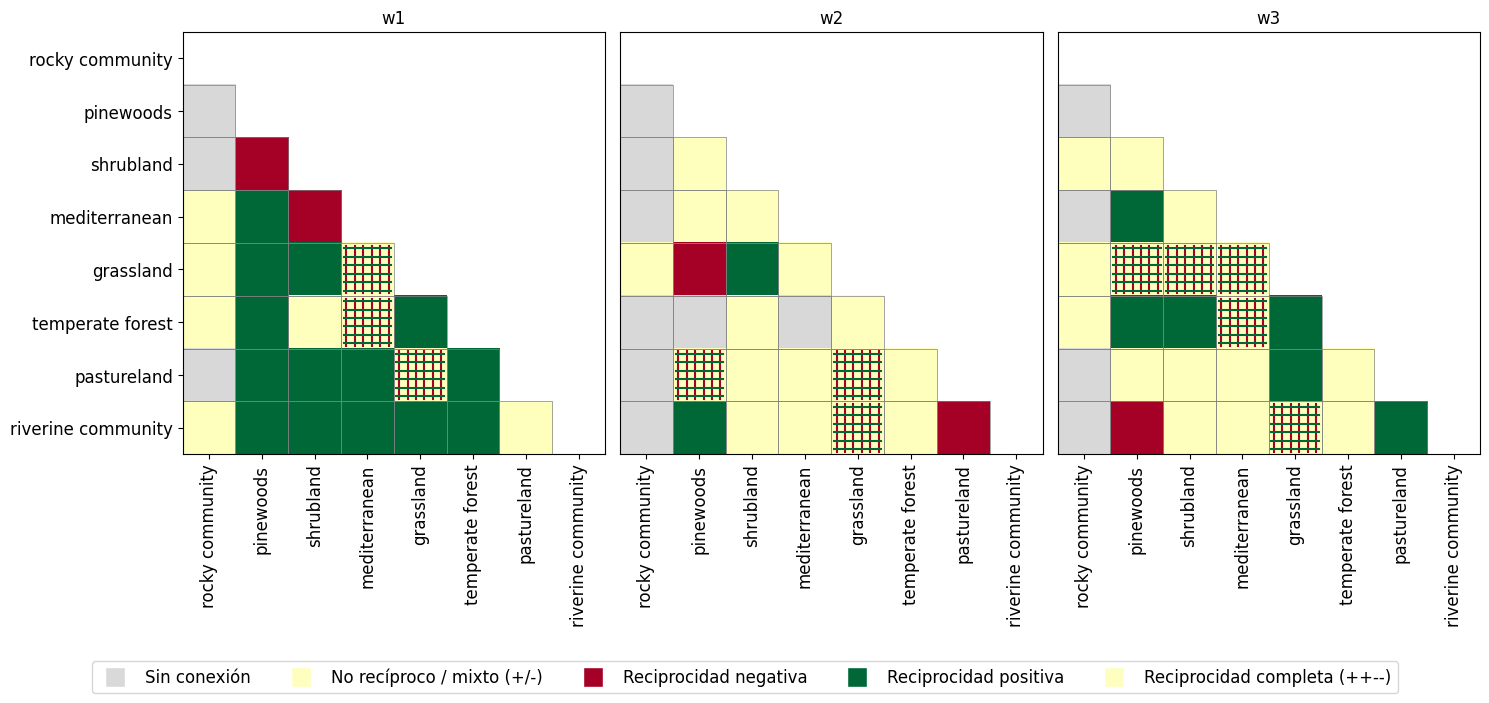

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from matplotlib.lines import Line2D

# =========================
# PRESENCIA DE SIGNO
# =========================
def construir_presencia_signo(mat_sig, especies, species_to_community):
    comunidades = sorted(set(
        species_to_community[sp] for sp in especies if sp in species_to_community
    ))
    
    idx = {c: i for i, c in enumerate(comunidades)}
    n = len(comunidades)
    
    pos = np.zeros((n, n), dtype=int)
    neg = np.zeros((n, n), dtype=int)
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = idx[species_to_community[sp_i]]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            if i == j:
                continue
            
            cj = idx[species_to_community[sp_j]]
            val = mat_sig[i][j]
            
            if val == 1:
                pos[ci, cj] = 1
            elif val == -1:
                neg[ci, cj] = 1
    
    return pos, neg, comunidades


# =========================
# MATRIZ TIPO PARES
# =========================
def matriz_tipo_pares_v3(mat_sig, especies, species_to_community):
    pos, neg, comunidades = construir_presencia_signo(
        mat_sig, especies, species_to_community
    )
    
    n = len(comunidades)
    M = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            
            pos_ij, neg_ij = pos[i,j], neg[i,j]
            pos_ji, neg_ji = pos[j,i], neg[j,i]
            
            hay_ij = pos_ij or neg_ij
            hay_ji = pos_ji or neg_ji
            
            if not (hay_ij or hay_ji):
                M[i,j] = M[j,i] = -2
            
            elif not (hay_ij and hay_ji):
                M[i,j] = M[j,i] = 0
            
            else:
                if pos_ij and neg_ij and pos_ji and neg_ji:
                    M[i,j] = M[j,i] = 2
                elif pos_ij and pos_ji:
                    M[i,j] = M[j,i] = 1
                elif neg_ij and neg_ji:
                    M[i,j] = M[j,i] = -1
                else:
                    M[i,j] = M[j,i] = 0
    
    return M, comunidades


# =========================
# ORDEN FIJO (usando w1)
# =========================
M_ref, comunidades = matriz_tipo_pares_v3(
    datos[0]["matriz_significancia"],
    datos[0]["especies"],
    species_to_community
)

dist = pdist(M_ref, metric='euclidean')
Z = linkage(dist, method='average')
order = leaves_list(Z)

comunidades_ord = [comunidades[i] for i in order]

# =========================
# GENERAR MATRICES ORDENADAS
# =========================
matrices = []

for data in datos:
    M, comunidades = matriz_tipo_pares_v3(
        data["matriz_significancia"],
        data["especies"],
        species_to_community
    )
    
    M_ord = M[order][:, order]
    matrices.append(M_ord)

titulos = ["w1", "w2", "w3"]

# =========================
# COLORES
# =========================
base = plt.cm.RdYlGn

gray = (0.85, 0.85, 0.85)
red = base(0.0)
yellow = base(0.5)
green = base(1.0)

colores = [gray, red, yellow, green, yellow]

cmap = mcolors.ListedColormap(colores)
bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for k, ax in enumerate(axes):
    
    M = matrices[k]
    
    # máscara: ocultar triángulo SUPERIOR
    tri_mask = np.triu(np.ones_like(M, dtype=bool))
    M_plot = np.ma.masked_where(tri_mask, M)
    
    im = ax.imshow(M_plot, cmap=cmap, norm=norm)
    
    # etiquetas
    ax.set_xticks(range(len(comunidades_ord)))
    ax.set_xticklabels(comunidades_ord, rotation=90, fontsize=12)
    
    ax.set_yticks(range(len(comunidades_ord)))
    ax.set_yticklabels(comunidades_ord, fontsize=12)
    
    ax.set_title(titulos[k])
    
    # =========================
    # GRID SOLO EN TRIÁNGULO INFERIOR
    # =========================
    n = len(comunidades_ord)
    for i in range(n):
        for j in range(n):
            if i > j:  # solo inferior
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                               fill=False, edgecolor='gray', linewidth=0.5))
    
    # =========================
    # HATCH PARA ++--
    # =========================
    mask_2 = (M == 2) & (~tri_mask)
    y, x = np.where(mask_2)
    
    for xi, yi in zip(x, y):
        # líneas rojas
        for offset in np.linspace(-0.4, 0.4, 6):
            ax.plot([xi + offset, xi + offset],
                    [yi - 0.45, yi + 0.45],
                    color=red, linewidth=1.5)
        
        # líneas verdes
        for offset in np.linspace(-0.4, 0.4, 6):
            ax.plot([xi - 0.45, xi + 0.45],
                    [yi + offset, yi + offset],
                    color=green, linewidth=1.5)

# ocultar eje Y en 2 y 3
axes[1].set_yticks([])
axes[2].set_yticks([])

# =========================
# LEYENDA
# =========================
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Sin conexión',
           markerfacecolor=gray, markersize=15),
    Line2D([0], [0], marker='s', color='w', label='No recíproco / mixto (+/-)',
           markerfacecolor=yellow, markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Reciprocidad negativa',
           markerfacecolor=red, markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Reciprocidad positiva',
           markerfacecolor=green, markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Reciprocidad completa (++--)',
           markerfacecolor=yellow, markersize=15)
]

fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, -0.17), ncol=5, fontsize=12)

plt.tight_layout()
plt.show()

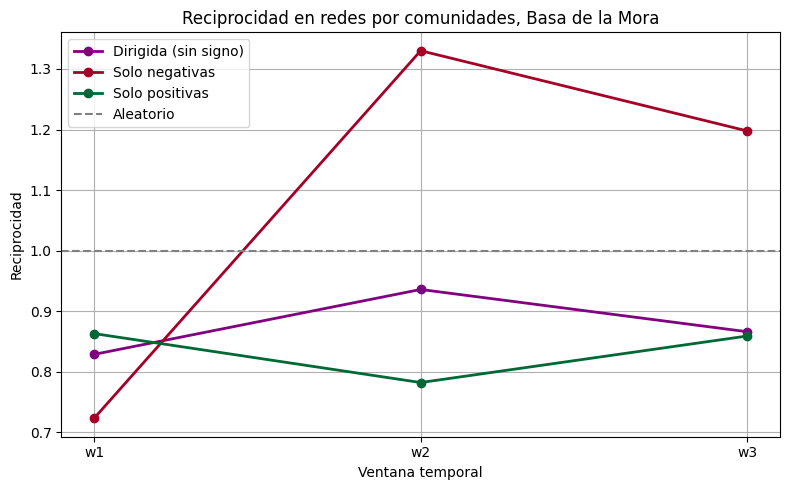

In [29]:
# --- función para construir grafo dirigido ---
def construir_grafo_dir(mat_sig, especies, species_to_community, tipo="all"):
    G = nx.DiGraph()
    
    for sp in especies:
        if sp in species_to_community:
            G.add_node(species_to_community[sp])
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = species_to_community[sp_i]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            if i == j:
                continue
            
            cj = species_to_community[sp_j]
            val = mat_sig[i][j]
            
            if val == 0:
                continue
            
            # filtrar según tipo
            if tipo == "pos" and val != 1:
                continue
            if tipo == "neg" and val != -1:
                continue
            
            # ignoramos signo en la estructura
            G.add_edge(ci, cj)
    
    return G



N_ITER = 1000

def reciprocidad_media_aleatoria(n_nodes, n_edges, n_iter=N_ITER):
    """Media de reciprocidad sobre n_iter grafos aleatorios con mismos nodos y aristas."""
    if n_nodes < 2 or n_edges == 0:
        return np.nan
    p = n_edges / float(n_nodes * (n_nodes - 1))
    vals = []
    for _ in range(n_iter):
        G_al = nx.gnp_random_graph(n_nodes, p, directed=True)
        r = nx.reciprocity(G_al)
        if r is not None:
            vals.append(r)
    return np.mean(vals) if vals else np.nan

rec_all, rec_pos, rec_neg = [], [], []
rec_aleat_all, rec_aleat_pos, rec_aleat_neg = [], [], []

for data in datos:
    especies = data["especies"]
    mat_sig  = data["matriz_significancia"]
    
    G_all = construir_grafo_dir(mat_sig, especies, species_to_community, "all")
    G_pos = construir_grafo_dir(mat_sig, especies, species_to_community, "pos")
    G_neg = construir_grafo_dir(mat_sig, especies, species_to_community, "neg")

    n_all, e_all = len(G_all.nodes()), len(G_all.edges())
    n_pos, e_pos = len(G_pos.nodes()), len(G_pos.edges())
    n_neg, e_neg = len(G_neg.nodes()), len(G_neg.edges())

    rec_all.append(nx.reciprocity(G_all))
    rec_pos.append(nx.reciprocity(G_pos))
    rec_neg.append(nx.reciprocity(G_neg))

    rec_aleat_all.append(reciprocidad_media_aleatoria(n_all, e_all))
    rec_aleat_pos.append(reciprocidad_media_aleatoria(n_pos, e_pos))
    rec_aleat_neg.append(reciprocidad_media_aleatoria(n_neg, e_neg))

# Convertir a arrays para operar
rec_all      = np.array(rec_all)
rec_pos      = np.array(rec_pos)
rec_neg      = np.array(rec_neg)
rec_aleat_all = np.array(rec_aleat_all)
rec_aleat_pos = np.array(rec_aleat_pos)
rec_aleat_neg = np.array(rec_aleat_neg)


# --- plot ---
x = np.arange(1, len(rec_all) + 1)

plt.figure(figsize=(8,5))



plt.plot(x, rec_all/rec_aleat_all, marker='o', linewidth=2, color='purple', label='Dirigida (sin signo)')
plt.plot(x, rec_neg/rec_aleat_neg, marker='o', linewidth=2, color=red, label='Solo negativas')
plt.plot(x, rec_pos/rec_aleat_pos, marker='o', linewidth=2, color=green, label='Solo positivas')
plt.axhline(1, color='gray', linestyle='--', label='Aleatorio')

plt.xticks(x, ["w1", "w2", "w3"])
plt.xlabel("Ventana temporal")
plt.ylabel("Reciprocidad")
plt.title("Reciprocidad en redes por comunidades, Basa de la Mora")

plt.legend()
plt.grid(True)
#plt.ylim(0,1)

plt.tight_layout()
plt.show()

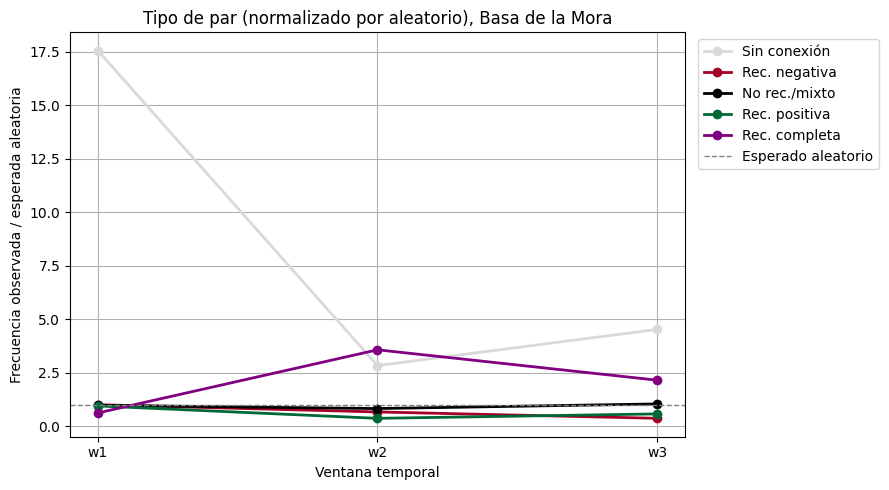

In [30]:
N_ITER = 1000

def categorias_frecuencia(M):
    """Cuenta frecuencia de cada categoría en el triángulo inferior."""
    n = M.shape[0]
    conteo = {-2: 0, -1: 0, 0: 0, 1: 0, 2: 0}
    total = 0
    for i in range(n):
        for j in range(i+1, n):
            conteo[M[i,j]] += 1
            total += 1
    return {k: v/total for k, v in conteo.items()} if total > 0 else conteo

def frecuencias_aleatorias_media(pos, neg, n_iter=N_ITER):
    """Media de frecuencias de categorías sobre n_iter redes aleatorias."""
    n = pos.shape[0]
    pares_dirigidos = [(i, j) for i in range(n) for j in range(n) if i != j]
    n_pares = len(pares_dirigidos)
    n_pos = int(pos.sum())
    n_neg = int(neg.sum())

    acum = {-2: [], -1: [], 0: [], 1: [], 2: []}

    for _ in range(n_iter):
        idx_pos = np.random.choice(n_pares, n_pos, replace=False)
        idx_neg = np.random.choice(n_pares, n_neg, replace=False)

        pos_al = np.zeros((n, n), dtype=int)
        neg_al = np.zeros((n, n), dtype=int)
        for k in idx_pos:
            i, j = pares_dirigidos[k]
            pos_al[i, j] = 1
        for k in idx_neg:
            i, j = pares_dirigidos[k]
            neg_al[i, j] = 1

        # Reutilizar matriz_tipo_pares_v3 pero pasando pos/neg directamente
        M_al = _matriz_desde_pos_neg(pos_al, neg_al)
        freqs = categorias_frecuencia(M_al)
        for cat, v in freqs.items():
            acum[cat].append(v)

    return {cat: np.mean(vals) for cat, vals in acum.items()}

def _matriz_desde_pos_neg(pos, neg):
    """Construye la matriz de categorías directamente desde pos y neg."""
    n = pos.shape[0]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            pos_ij, neg_ij = pos[i,j], neg[i,j]
            pos_ji, neg_ji = pos[j,i], neg[j,i]
            hay_ij = pos_ij or neg_ij
            hay_ji = pos_ji or neg_ji
            if not (hay_ij or hay_ji):
                M[i,j] = M[j,i] = -2
            elif not (hay_ij and hay_ji):
                M[i,j] = M[j,i] = 0
            else:
                if pos_ij and neg_ij and pos_ji and neg_ji:
                    M[i,j] = M[j,i] = 2
                elif pos_ij and pos_ji:
                    M[i,j] = M[j,i] = 1
                elif neg_ij and neg_ji:
                    M[i,j] = M[j,i] = -1
                else:
                    M[i,j] = M[j,i] = 0
    return M

# --- Calcular frecuencias observadas y aleatorias por ventana ---
categorias = [-2, -1, 0, 1, 2]
labels_cat = {-2: 'Sin conexión', -1: 'Rec. negativa', 0: 'No rec./mixto',
               1: 'Rec. positiva', 2: 'Rec. completa'}
colores_cat = {-2: gray, -1: red, 0: "black", 1: green, 2: 'purple'}

freqs_obs   = []  # frecuencias observadas por ventana
freqs_aleat = []  # frecuencias aleatorias por ventana

for data in datos:
    pos, neg, _ = construir_presencia_signo(
        data["matriz_significancia"], data["especies"], species_to_community)
    M = _matriz_desde_pos_neg(pos, neg)
    freqs_obs.append(categorias_frecuencia(M))
    freqs_aleat.append(frecuencias_aleatorias_media(pos, neg))

# --- Plot: ratio observado/aleatorio por categoría y ventana ---
x = np.arange(1, len(datos) + 1)
fig, ax = plt.subplots(figsize=(9, 5))

for cat in categorias:
    obs   = np.array([f[cat] for f in freqs_obs])
    aleat = np.array([f[cat] for f in freqs_aleat])
    ratio = obs / np.where(aleat == 0, np.nan, aleat)
    ax.plot(x, ratio, marker='o', linewidth=2,
            label=labels_cat[cat], color=colores_cat[cat])

ax.axhline(1, color='gray', linestyle='--', linewidth=1, label='Esperado aleatorio')
ax.set_xticks(x)
ax.set_xticklabels(["w1", "w2", "w3"])
ax.set_xlabel("Ventana temporal")
ax.set_ylabel("Frecuencia observada / esperada aleatoria")
ax.set_title("Tipo de par (normalizado por aleatorio), Basa de la Mora")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

# k_in y k_out por comunidad

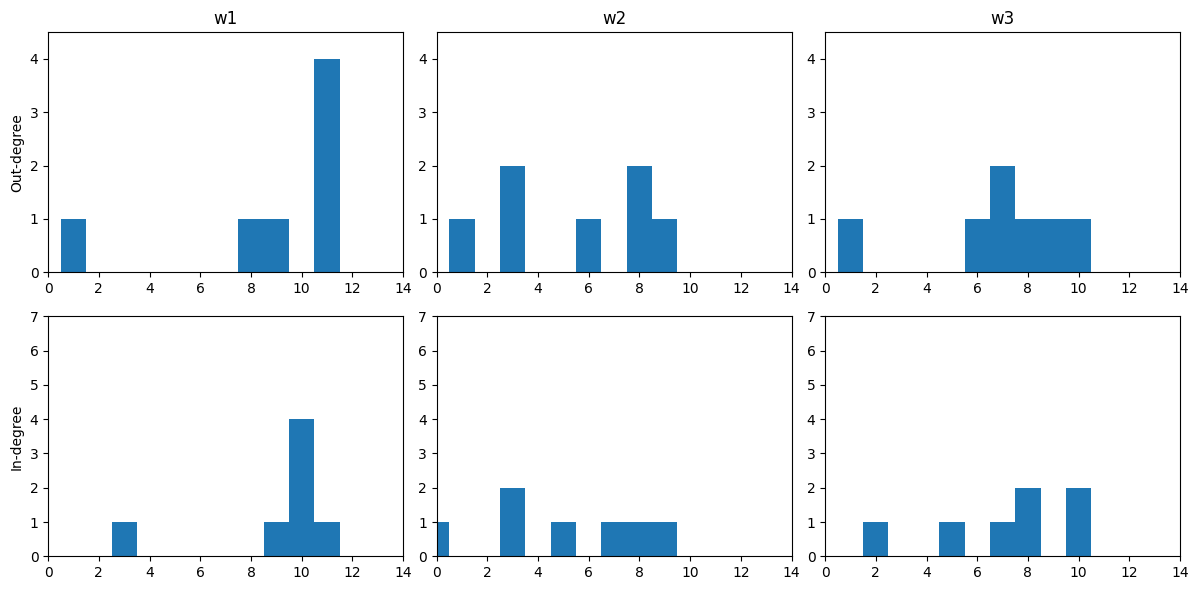

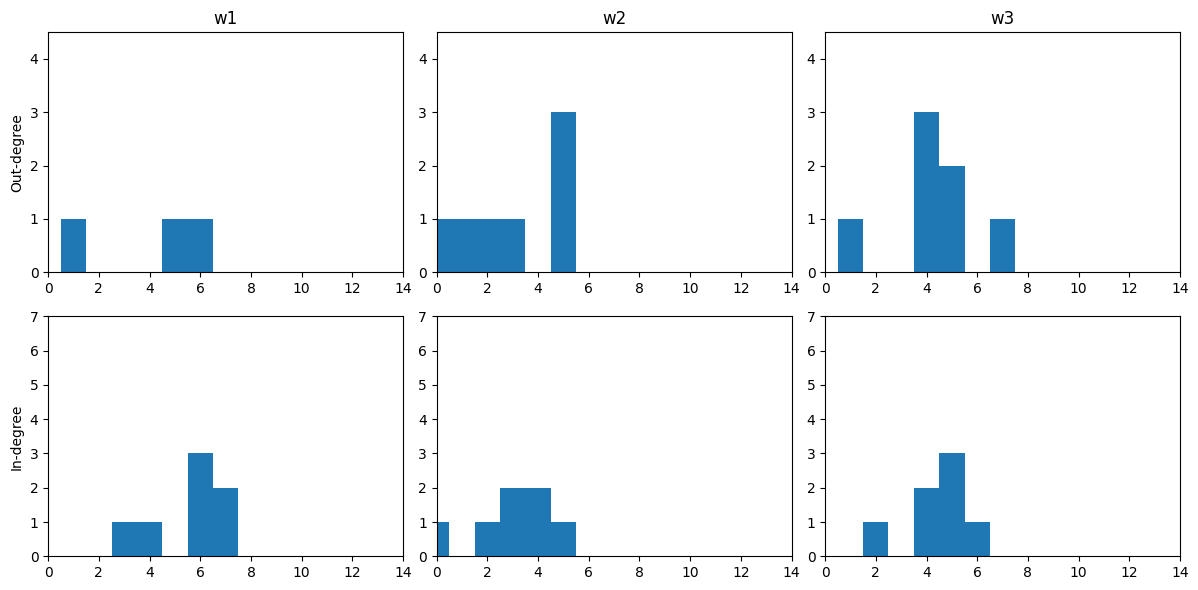

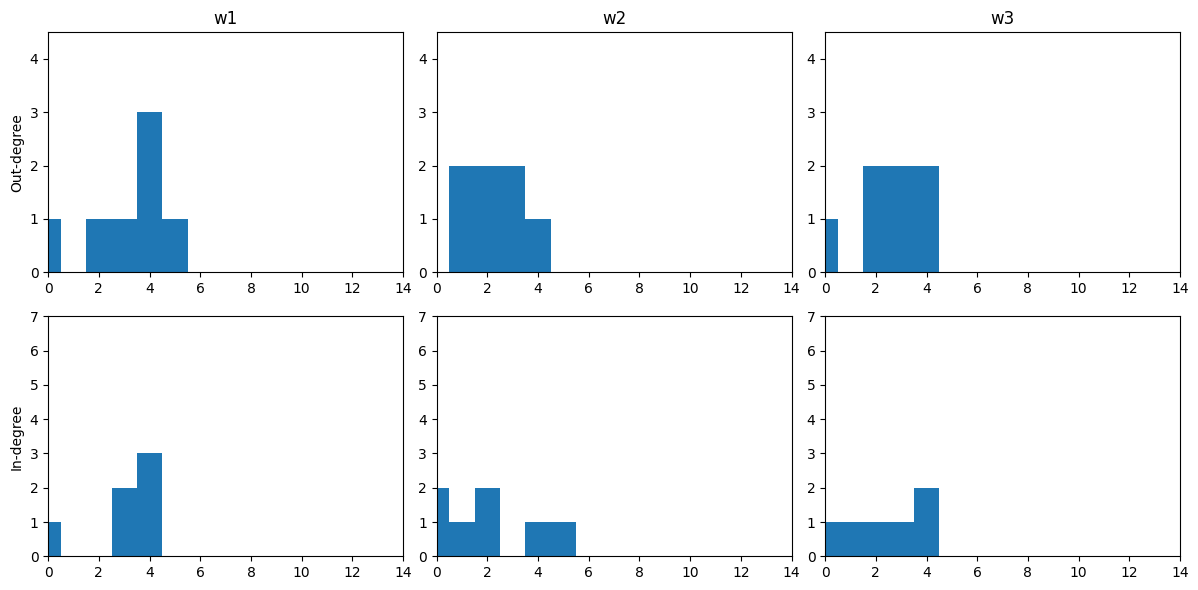

In [143]:
def construir_matriz_presencia(mat_sig, especies, species_to_community, tipo="all"):
    comunidades = sorted(set(
        species_to_community[sp] for sp in especies if sp in species_to_community
    ))
    
    idx = {c: i for i, c in enumerate(comunidades)}
    n = len(comunidades)
    
    pos = np.zeros((n, n))
    neg = np.zeros((n, n))
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = idx[species_to_community[sp_i]]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            if i == j:
                continue
            
            cj = idx[species_to_community[sp_j]]
            val = mat_sig[i][j]
            
            if val == 1:
                pos[ci, cj] = 1
            elif val == -1:
                neg[ci, cj] = 1
    
    if tipo == "all":
        W = pos + neg   # puede ser 0,1,2
    elif tipo == "pos":
        W = pos
    elif tipo == "neg":
        W = neg
    
    return W, comunidades


def plot_grados(tipo, titulo):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    
    for t, data in enumerate(datos):
        especies = data["especies"]
        mat_sig = data["matriz_significancia"]
        
        W, comunidades = construir_matriz_presencia(
            mat_sig, especies, species_to_community, tipo
        )
        
        out_deg = np.sum(W, axis=1)
        in_deg = np.sum(W, axis=0)
        
        axes[0, t].hist(out_deg, bins=np.arange(-0.5, np.max(out_deg) + 0.5))
        axes[0, t].set_title(f"w{t+1}")
        
        axes[1, t].hist(in_deg, bins=np.arange(-0.5, np.max(in_deg) + 0.5))

        axes[0, t].set_xlim(0, 14)
        axes[1, t].set_xlim(0, 14)
        axes[0, t].set_ylim(0, 4.5)
        axes[1, t].set_ylim(0, 7)
    
    axes[0, 0].set_ylabel("Out-degree")
    axes[1, 0].set_ylabel("In-degree")

    
    #fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()


# --- plots ---
plot_grados("all", "Grado (máx 4 enlaces por par)")
plot_grados("pos", "Grado (solo positivos)")
plot_grados("neg", "Grado (solo negativos)")

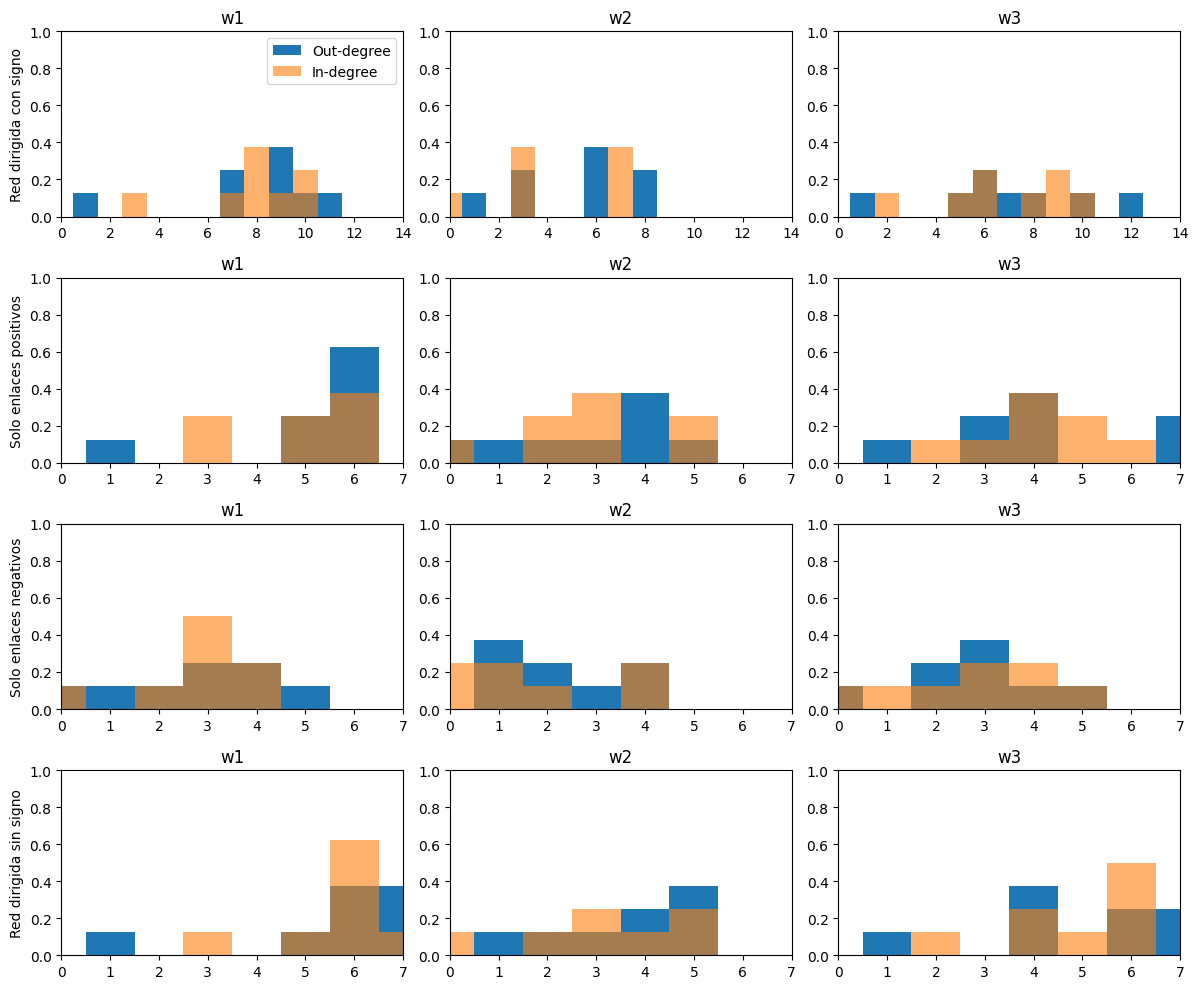

In [186]:
def construir_matriz_presencia(mat_sig, especies, species_to_community, tipo="all"):
    
    comunidades = sorted(set(
        species_to_community[sp] for sp in especies if sp in species_to_community
    ))
    
    idx = {c: i for i, c in enumerate(comunidades)}
    n = len(comunidades)
    
    pos = np.zeros((n, n))
    neg = np.zeros((n, n))
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = idx[species_to_community[sp_i]]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            if i == j:
                continue
            
            cj = idx[species_to_community[sp_j]]
            val = mat_sig[i][j]
            
            if val == 1:
                pos[ci, cj] = 1
            elif val == -1:
                neg[ci, cj] = 1
    
    # 🔥 FIX CRUCIAL: eliminar auto-enlaces comunitarios
    np.fill_diagonal(pos, 0)
    np.fill_diagonal(neg, 0)
    
    if tipo == "all":
        W = pos + neg
    elif tipo == "pos":
        W = pos
    elif tipo == "neg":
        W = neg
    elif tipo == "unsigned":
        W = (pos + neg > 0).astype(int)
    
    return W, comunidades

def plot_grados_todos():
    
    tipos = ["all", "pos", "neg", "unsigned"]
    titulos_fila = [
        "Red dirigida con signo",
        "Solo enlaces positivos",
        "Solo enlaces negativos",
        "Red dirigida sin signo"
    ]
    
    fig, axes = plt.subplots(4, 3, figsize=(12, 10))
    
    for f, tipo in enumerate(tipos):
        for t, data in enumerate(datos):
            
            especies = data["especies"]
            mat_sig = data["matriz_significancia"]
            
            W, comunidades = construir_matriz_presencia(
                mat_sig, especies, species_to_community, tipo
            )
            
            out_deg = np.sum(W, axis=1)
            in_deg = np.sum(W, axis=0)

            # if tipo == "all":
            #     max_deg = 2 * (len(comunidades) - 1)
            # else:
            #     max_deg = (len(comunidades) - 1)

            # out_deg_norm = out_deg / max_deg
            # in_deg_norm  = in_deg  / max_deg
            weights_out = np.ones_like(out_deg) / len(out_deg)
            weights_in  = np.ones_like(in_deg) / len(in_deg)

            bins = np.arange(-0.5, np.max(out_deg) + 1.5, 1)
            # print("n comunidades:", len(comunidades))
            # print("max out-degree observado:", np.max(np.sum(W, axis=1)))
            # print("matriz única valores:", np.unique(W))
            axes[f, t].hist(out_deg, bins=bins, weights=weights_out)
            axes[f, t].hist(in_deg, bins=bins, weights=weights_in, alpha=0.6)

            # OUT arriba de cada bloque
            #axes[f, t].hist(out_deg_norm)
            axes[f, t].set_title(f"w{t+1}")
            
            # límites consistentes
            
            axes[f, t].set_xlim(0, 7)
            axes[0, t].set_xlim(0, 14)
            axes[f, t].set_ylim(0, 1)
        
        # etiqueta de fila
        axes[f, 0].set_ylabel(titulos_fila[f])
    
    #plt.suptitle("K_out", fontsize=16)
    axes[0, 0].legend(["Out-degree", "In-degree"], loc='upper right')
    plt.tight_layout()
    plt.show()


plot_grados_todos()

# local balance comunidades

In [ ]:
# construir A a nivel de especies (tu función original)
def construir_A_especies(mat_sig):
    n = len(mat_sig)
    A = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            a_ij = mat_sig[i][j]
            a_ji = mat_sig[j][i]

            if a_ij == 0 and a_ji == 0:
                continue

            if a_ij * a_ji == -1:
                continue

            sign = a_ij if a_ij != 0 else a_ji
            A[i, j] = sign
            A[j, i] = sign

    return A

resultados_comunidades = {}

for data in datos:
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    A = construir_A_especies(mat_sig)
    
    k_local = calcular_k_local(A)
    SC = calcular_SC(A)
    
    # agrupar por comunidad
    for i, sp in enumerate(especies):
        if sp not in species_to_community:
            continue
        
        com = species_to_community[sp]
        
        if com not in resultados_comunidades:
            resultados_comunidades[com] = {
                "k": [],
                "SC": []
            }
        
        resultados_comunidades[com]["k"].append(k_local[i])
        resultados_comunidades[com]["SC"].append(SC[i])

k_com = {}
SC_com = {}

for com, vals in resultados_comunidades.items():
    k_com[com] = np.nanmean(vals["k"])
    SC_com[com] = np.nanmean(vals["SC"])



{'pinewoods': np.float64(0.7327701043045335),
 'shrubland': np.float64(0.8136962652550399),
 'temperate forest': np.float64(0.8156672171914789),
 'riverine community': np.float64(0.7557933992330403),
 'mediterranean': np.float64(0.7559978148577496),
 'grassland': np.float64(0.7819528021145651),
 'pastureland': np.float64(0.782714799724673),
 'rocky community': np.float64(0.8444793016212412)}

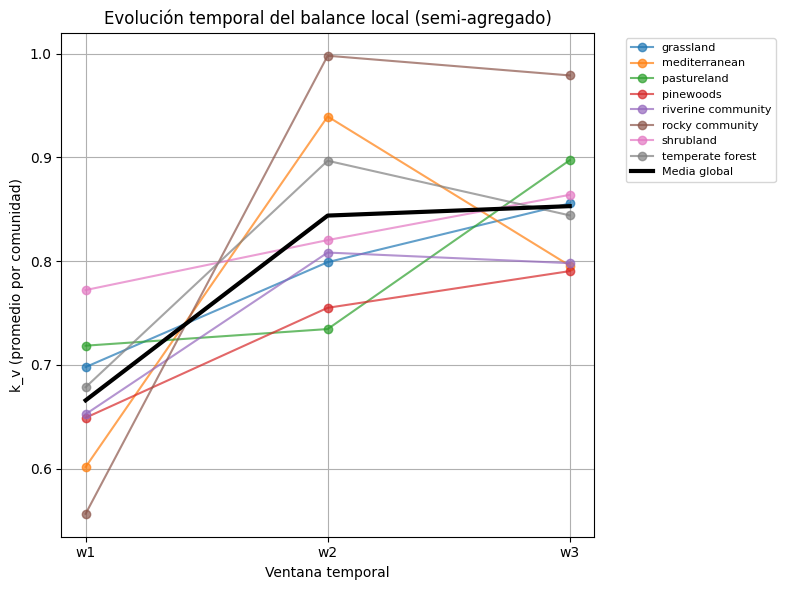

In [64]:
# --- inicializar ---
todas_comunidades = sorted(set(species_to_community.values()))
idx_global = {c: i for i, c in enumerate(todas_comunidades)}

k_all = np.full((len(datos), len(todas_comunidades)), np.nan)

# --- rellenar ---
for t, data in enumerate(datos):
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    A = construir_A_especies(mat_sig)
    k_local = calcular_k_local(A)
    
    # acumular por comunidad
    tmp = {c: [] for c in todas_comunidades}
    
    for i, sp in enumerate(especies):
        if sp not in species_to_community:
            continue
        com = species_to_community[sp]
        tmp[com].append(k_local[i])
    
    # promedio por comunidad
    for com in todas_comunidades:
        vals = tmp[com]
        if len(vals) > 0:
            k_all[t, idx_global[com]] = np.nanmean(vals)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for com in todas_comunidades:
    i = idx_global[com]
    plt.plot([1,2,3], k_all[:, i], marker='o', alpha=0.7, label=com)

media_global = np.nanmean(k_all, axis=1)
plt.plot([1,2,3], media_global, color='black', linewidth=3, label='Media global')

plt.xlabel("Ventana temporal")
plt.ylabel("k_v (promedio por comunidad)")
plt.title("Evolución temporal del balance local (semi-agregado)")

plt.xticks([1,2,3], ["w1", "w2", "w3"])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.grid(True)
plt.tight_layout()
plt.show()

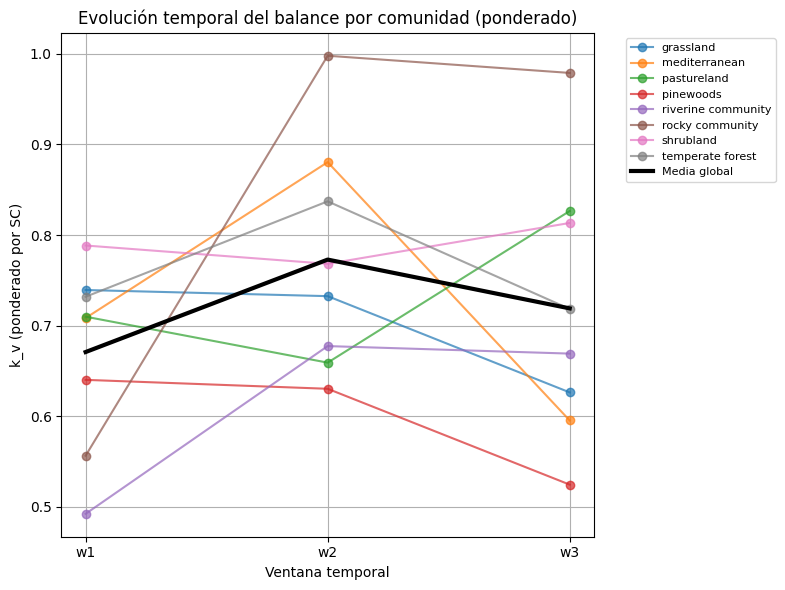

In [66]:
# --- inicializar ---
todas_comunidades = sorted(set(species_to_community.values()))
idx_global = {c: i for i, c in enumerate(todas_comunidades)}

k_all = np.full((len(datos), len(todas_comunidades)), np.nan)

# --- loop temporal ---
for t, data in enumerate(datos):
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    A = construir_A_especies(mat_sig)
    
    k_local = calcular_k_local(A)
    SC = calcular_SC(A)  # IMPORTANTE: sin normalizar
    
    # acumular por comunidad
    tmp_k = {c: [] for c in todas_comunidades}
    tmp_SC = {c: [] for c in todas_comunidades}
    
    for i, sp in enumerate(especies):
        if sp not in species_to_community:
            continue
        
        com = species_to_community[sp]
        tmp_k[com].append(k_local[i])
        tmp_SC[com].append(SC[i])
    
    # promedio ponderado por SC
    for com in todas_comunidades:
        k_vals = np.array(tmp_k[com])
        sc_vals = np.array(tmp_SC[com])
        
        mask = ~np.isnan(k_vals) & ~np.isnan(sc_vals)
        
        if np.sum(mask) == 0:
            continue
        
        k_vals = k_vals[mask]
        sc_vals = sc_vals[mask]
        
        if np.sum(sc_vals) == 0:
            k_all[t, idx_global[com]] = np.nan
        else:
            k_all[t, idx_global[com]] = np.sum(k_vals * sc_vals) / np.sum(sc_vals)

plt.figure(figsize=(8,6))

for com in todas_comunidades:
    i = idx_global[com]
    plt.plot([1,2,3], k_all[:, i], marker='o', alpha=0.7, label=com)

plt.plot([1,2,3], np.nanmean(k_all, axis=1), color='black', linewidth=3, label='Media global')

plt.xlabel("Ventana temporal")
plt.ylabel("k_v (ponderado por SC)")
plt.title("Evolución temporal del balance por comunidad (ponderado)")

plt.xticks([1,2,3], ["w1", "w2", "w3"])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# temporalidad

In [31]:
def construir_enlaces_dirigidos(mat_sig, especies, species_to_community):
    enlaces = set()
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = species_to_community[sp_i]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            if i == j:
                continue
            
            cj = species_to_community[sp_j]
            val = mat_sig[i][j]
            
            if val == 0:
                continue
            
            # enlace dirigido con signo
            enlaces.add((ci, cj, int(val)))
    
    return enlaces

redes_dir = []

for data in datos:
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    enlaces = construir_enlaces_dirigidos(mat_sig, especies, species_to_community)
    redes_dir.append(enlaces)


temporalidad = []

for t in range(1, len(redes_dir)):
    E_prev = redes_dir[t-1]
    E_curr = redes_dir[t]
    
    inter = len(E_prev & E_curr)
    union = len(E_prev | E_curr)
    
    if union == 0:
        T = np.nan
    else:
        T = 1 - inter / union
    
    temporalidad.append(T)

E_prev = redes_dir[0]
E_curr = redes_dir[2]

inter = len(E_prev & E_curr)
union = len(E_prev | E_curr)

if union == 0:
    T = np.nan
else:
    T = 1 - inter / union

temporalidad.append(T)


for i, T in enumerate(temporalidad):
    print(f"Temporalidad entre red {i+1} y red {i+2}: {T:.4f}")

Temporalidad entre red 1 y red 2: 0.6180
Temporalidad entre red 2 y red 3: 0.6076
Temporalidad entre red 3 y red 4: 0.4607


In [32]:
def construir_enlaces_dir_sin_signo(mat_sig, especies, species_to_community):
    enlaces = set()
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = species_to_community[sp_i]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            if i == j:
                continue
            
            cj = species_to_community[sp_j]
            val = mat_sig[i][j]
            
            if val == 0:
                continue
            
            # ignoramos el signo
            enlaces.add((ci, cj))
    
    return enlaces

redes_dir_sin_signo = []

for data in datos:
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    enlaces = construir_enlaces_dir_sin_signo(mat_sig, especies, species_to_community)
    redes_dir_sin_signo.append(enlaces)

temporalidad_sin_signo = []

for t in range(1, len(redes_dir_sin_signo)):
    E_prev = redes_dir_sin_signo[t-1]
    E_curr = redes_dir_sin_signo[t]
    
    inter = len(E_prev & E_curr)
    union = len(E_prev | E_curr)
    
    if union == 0:
        T = np.nan
    else:
        T = 1 - inter / union
    
    temporalidad_sin_signo.append(T)

E_prev = redes_dir_sin_signo[0]
E_curr = redes_dir_sin_signo[2]

inter = len(E_prev & E_curr)
union = len(E_prev | E_curr)

if union == 0:
    T = np.nan
else:
    T = 1 - inter / union

temporalidad_sin_signo.append(T)


for i, T in enumerate(temporalidad_sin_signo):
    print(f"Temporalidad (sin signo) entre red {i+1} y red {i+2}: {T:.4f}")

Temporalidad (sin signo) entre red 1 y red 2: 0.3962
Temporalidad (sin signo) entre red 2 y red 3: 0.4286
Temporalidad (sin signo) entre red 3 y red 4: 0.2545


In [33]:
import numpy as np

# --- función: construir enlaces no dirigidos sin signo ---
def construir_enlaces_no_dir(mat_sig, especies, species_to_community):
    enlaces = set()
    
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = species_to_community[sp_i]
        
        for j in range(i+1, len(especies)):  # solo mitad superior
            sp_j = especies[j]
            if sp_j not in species_to_community:
                continue
            
            cj = species_to_community[sp_j]
            
            if ci == cj:
                continue
            
            # mirar ambas direcciones
            val_ij = mat_sig[i][j]
            val_ji = mat_sig[j][i]
            
            if val_ij != 0 or val_ji != 0:
                # enlace no dirigido → ordenado para evitar duplicados
                enlace = tuple(sorted((ci, cj)))
                enlaces.add(enlace)
    
    return enlaces


# --- construir redes ---
redes_no_dir = []

for data in datos:
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    enlaces = construir_enlaces_no_dir(mat_sig, especies, species_to_community)
    redes_no_dir.append(enlaces)


# --- calcular temporalidad ---
temporalidad_no_dir = []

for t in range(1, len(redes_no_dir)):
    E_prev = redes_no_dir[t-1]
    E_curr = redes_no_dir[t]
    
    inter = len(E_prev & E_curr)
    union = len(E_prev | E_curr)
    
    if union == 0:
        T = np.nan
    else:
        T = 1 - inter / union
    
    temporalidad_no_dir.append(T)

E_prev = redes_no_dir[0]
E_curr = redes_no_dir[2]

inter = len(E_prev & E_curr)
union = len(E_prev | E_curr)

if union == 0:
    T = np.nan
else:
    T = 1 - inter / union

temporalidad_no_dir.append(T)

# --- mostrar resultados ---
for i, T in enumerate(temporalidad_no_dir):
    print(f"Temporalidad (no dirigida, sin signo) entre red {i+1} y red {i+2}: {T:.4f}")

Temporalidad (no dirigida, sin signo) entre red 1 y red 2: 0.2000
Temporalidad (no dirigida, sin signo) entre red 2 y red 3: 0.1667
Temporalidad (no dirigida, sin signo) entre red 3 y red 4: 0.1154


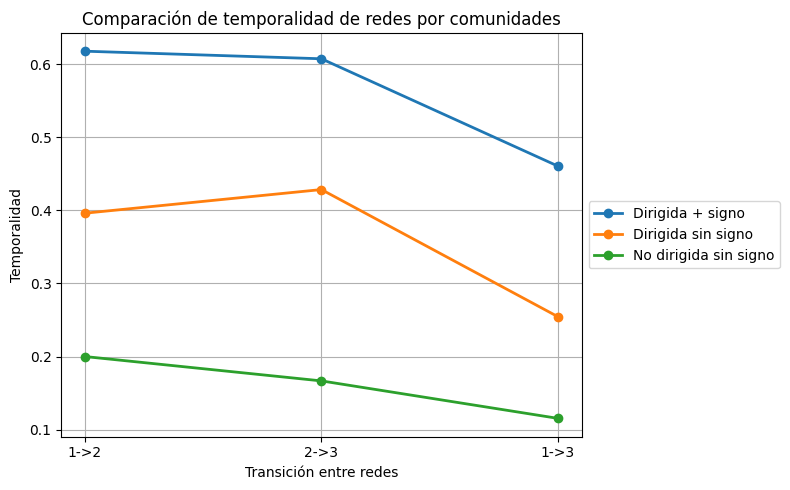

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# eje x: transiciones
x_temp = np.arange(1, len(temporalidad) + 1)

labels = [f"{i}->{i+1}" for i in range(1, len(temporalidad) + 1)]
labels = [f"1->2", f"2->3", f"1->3"]

plt.figure(figsize=(8, 5))

# tres métricas
plt.plot(x_temp, temporalidad, marker='o', linewidth=2, label='Dirigida + signo')
plt.plot(x_temp, temporalidad_sin_signo, marker='o', linewidth=2, label='Dirigida sin signo')
plt.plot(x_temp, temporalidad_no_dir, marker='o', linewidth=2, label='No dirigida sin signo')

plt.xticks(x_temp, labels)
plt.xlabel("Transición entre redes")
plt.ylabel("Temporalidad")
plt.title("Comparación de temporalidad de redes por comunidades")

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

plt.tight_layout()
plt.show()

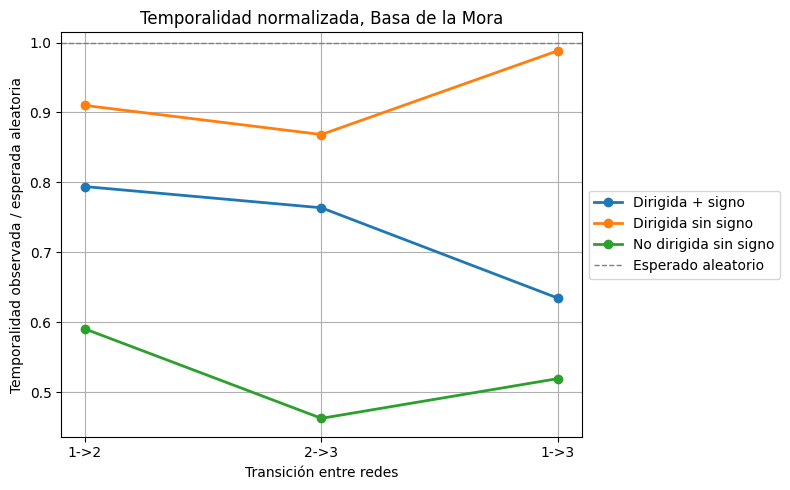


Temporalidad normalizada w1->w3:
  Dirigida + signo:    0.6346
  Dirigida sin signo:  0.9883
  No dirigida:         0.5196


In [41]:
import matplotlib.pyplot as plt
import numpy as np
import random

N_ITER = 1000

# =========================
# GENERADORES DE ALEATORIAS
# =========================

def generar_aleatoria_con_signo(red):
    nodos = sorted({n for e in red for n in e[:2]})
    todos_pares = [(c1, c2) for c1 in nodos for c2 in nodos if c1 != c2]
    pares_unicos = list({(e[0], e[1]) for e in red})
    if len(pares_unicos) > len(todos_pares):
        return set()
    seleccionados = random.sample(todos_pares, len(pares_unicos))
    return {(c1, c2, random.choice([1, -1])) for c1, c2 in seleccionados}

def generar_aleatoria_dirigida(red):
    nodos = sorted({n for e in red for n in e[:2]})
    todos_pares = [(c1, c2) for c1 in nodos for c2 in nodos if c1 != c2]
    pares_unicos = list({(e[0], e[1]) for e in red})
    if len(pares_unicos) > len(todos_pares):
        return set()
    return set(random.sample(todos_pares, len(pares_unicos)))

def generar_aleatoria_no_dirigida(red):
    nodos = sorted({n for e in red for n in e[:2]})
    todos_pares = [tuple(sorted((c1, c2)))
                   for i, c1 in enumerate(nodos)
                   for c2 in nodos[i+1:]]
    pares_unicos = list(red)  # ya son no dirigidos
    if len(pares_unicos) > len(todos_pares):
        return set()
    return set(map(tuple, random.sample(todos_pares, len(pares_unicos))))

# =========================
# TEMPORALIDAD
# =========================

def calcular_temporalidad(E_prev, E_curr):
    inter = len(E_prev & E_curr)
    union = len(E_prev | E_curr)
    if union == 0:
        return np.nan
    return 1 - inter / union

def temporalidad_media_aleatoria(generador, redes, i, j, n_iter=N_ITER):
    vals = []
    for _ in range(n_iter):
        al_i = generador(redes[i])
        al_j = generador(redes[j])
        if al_i and al_j:
            vals.append(calcular_temporalidad(al_i, al_j))
    return np.mean(vals) if vals else np.nan

# =========================
# PARES A COMPARAR
# (transiciones consecutivas + w1->w3)
# =========================
pares = [(0,1), (1,2), (0,2)]
labels = ["1->2", "2->3", "1->3"]

temp_dir, temp_sin_signo, temp_no_dir = [], [], []
base_dir, base_sin_signo, base_no_dir = [], [], []

for i, j in pares:
    # --- observado ---
    temp_dir.append(calcular_temporalidad(redes_dir[i], redes_dir[j]))
    temp_sin_signo.append(calcular_temporalidad(redes_dir_sin_signo[i], redes_dir_sin_signo[j]))
    temp_no_dir.append(calcular_temporalidad(redes_no_dir[i], redes_no_dir[j]))

    # --- baseline aleatorio ---
    base_dir.append(temporalidad_media_aleatoria(
        generar_aleatoria_con_signo, redes_dir, i, j))
    base_sin_signo.append(temporalidad_media_aleatoria(
        generar_aleatoria_dirigida, redes_dir_sin_signo, i, j))
    base_no_dir.append(temporalidad_media_aleatoria(
        generar_aleatoria_no_dirigida, redes_no_dir, i, j))

# Convertir y normalizar
temp_dir       = np.array(temp_dir)
temp_sin_signo = np.array(temp_sin_signo)
temp_no_dir    = np.array(temp_no_dir)
base_dir       = np.array(base_dir)
base_sin_signo = np.array(base_sin_signo)
base_no_dir    = np.array(base_no_dir)

norm_dir       = temp_dir       / base_dir
norm_sin_signo = temp_sin_signo / base_sin_signo
norm_no_dir    = temp_no_dir    / base_no_dir

# =========================
# PLOT: solo transiciones consecutivas (primeras 3)
# =========================
x = np.arange(1, 4)

plt.figure(figsize=(8, 5))
plt.plot(x, norm_dir[:3],       marker='o', linewidth=2, label='Dirigida + signo')
plt.plot(x, norm_sin_signo[:3], marker='o', linewidth=2, label='Dirigida sin signo')
plt.plot(x, norm_no_dir[:3],    marker='o', linewidth=2, label='No dirigida sin signo')
plt.axhline(1, color='gray', linestyle='--', linewidth=1, label='Esperado aleatorio')
plt.xticks(x, labels[:3])
plt.xlabel("Transición entre redes")
plt.ylabel("Temporalidad observada / esperada aleatoria")
plt.title("Temporalidad normalizada, Basa de la Mora")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

# Imprimir también w1->w3
print(f"\nTemporalidad normalizada w1->w3:")
print(f"  Dirigida + signo:    {norm_dir[2]:.4f}")
print(f"  Dirigida sin signo:  {norm_sin_signo[2]:.4f}")
print(f"  No dirigida:         {norm_no_dir[2]:.4f}")

# local balance

In [5]:
import pickle
import numpy as np
import pandas as pd
from scipy.linalg import expm

# --- funciones ---

def construir_A_comunidades(mat_sig, especies, species_to_community):
    # comunidades únicas presentes en este dataset
    comunidades = sorted(set(
        species_to_community[sp] for sp in especies if sp in species_to_community
    ))
    
    idx_com = {c: i for i, c in enumerate(comunidades)}
    n = len(comunidades)
    
    A = np.zeros((n, n))
    counts = {}

    # recorrer pares de especies
    for i, sp_i in enumerate(especies):
        if sp_i not in species_to_community:
            continue
        ci = species_to_community[sp_i]
        ii = idx_com[ci]
        
        for j, sp_j in enumerate(especies):
            if sp_j not in species_to_community:
                continue
            cj = species_to_community[sp_j]
            jj = idx_com[cj]
            
            if ii == jj:
                continue
            
            val = mat_sig[i][j]
            if val == 0:
                continue
            
            key = (ii, jj)
            if key not in counts:
                counts[key] = {1: 0, -1: 0}
            
            counts[key][val] += 1

    # decidir signo dominante
    for (ii, jj), c in counts.items():
        if c[1] > c[-1]:
            sign = 1
        elif c[-1] > c[1]:
            sign = -1
        else:
            sign = 0
        
        A[ii, jj] = sign
        A[jj, ii] = sign
    
    return A, comunidades


def calcular_SC(A):
    A_abs = np.abs(A)
    expA_abs = expm(A_abs)
    SC = np.diag(expA_abs)
    return SC


def calcular_k_local(A):
    A_abs = np.abs(A)
    expA = expm(A)
    expA_abs = expm(A_abs)
    
    k_local = np.diag(expA) / np.diag(expA_abs)
    return np.nan_to_num(k_local, nan=np.nan)


# --- cargar grupos ---
groups_df = pd.read_csv("basa_groups.csv")
species_to_community = dict(zip(groups_df["Taxa"], groups_df["Community"]))

# --- cargar datos ---
files = [
    "results_w1_wio.pkl",
    "results_w2_wio.pkl",
    "results_w3_wio.pkl"
]

datos = []
for f in files:
    with open(f, "rb") as file:
        data = pickle.load(file)
    datos.append(data)

# --- conjunto global de comunidades ---
todas_comunidades = sorted(set(species_to_community.values()))
idx_global = {c: i for i, c in enumerate(todas_comunidades)}

# --- matrices globales ---
k_all = np.full((len(files), len(todas_comunidades)), np.nan)
SC_all = np.full((len(files), len(todas_comunidades)), np.nan)

# --- procesamiento ---
for t, data in enumerate(datos):
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    A, comunidades = construir_A_comunidades(mat_sig, especies, species_to_community)
    
    if len(A) == 0:
        continue
    
    k_local = calcular_k_local(A)
    SC = calcular_SC(A)
    
    if np.nansum(SC) == 0:
        continue
    
    #SC_percent = 100 * SC / np.nansum(SC)
    
    # guardar en matriz global
    for i, c in enumerate(comunidades):
        j = idx_global[c]
        k_all[t, j] = k_local[i]
        #SC_all[t, j] = SC_percent[i]
        SC_all[t, j] = SC[i]



# --- resultado ---
print("k_all:")
print(k_all)

print("\nSC_all (%):")
print(SC_all)

k_all:
[[0.10239185 0.23240198 0.27135738 0.27135738 0.21174106 0.30327822
  0.0956476  0.18423144]
 [0.2731453  0.37929499 0.31727538 0.40693435 0.47503976 0.83551434
  0.5395849  0.40649272]
 [0.53360285 0.45792243 0.55360528 0.52495457 0.46952126 0.3831143
  0.54474206 0.30174212]]

SC_all (%):
[[85.09405364 85.09405364 71.44120546 71.44120546 85.09405364 34.54000818
  71.44120546 85.09405364]
 [16.38550324 14.92014896 11.09251198  7.98922303 14.92014896  2.08816593
  10.96141088 11.09251198]
 [21.76376744 23.57993467 24.2886693  30.81891383 16.88981722  9.65083806
  27.07276963 27.07276963]]


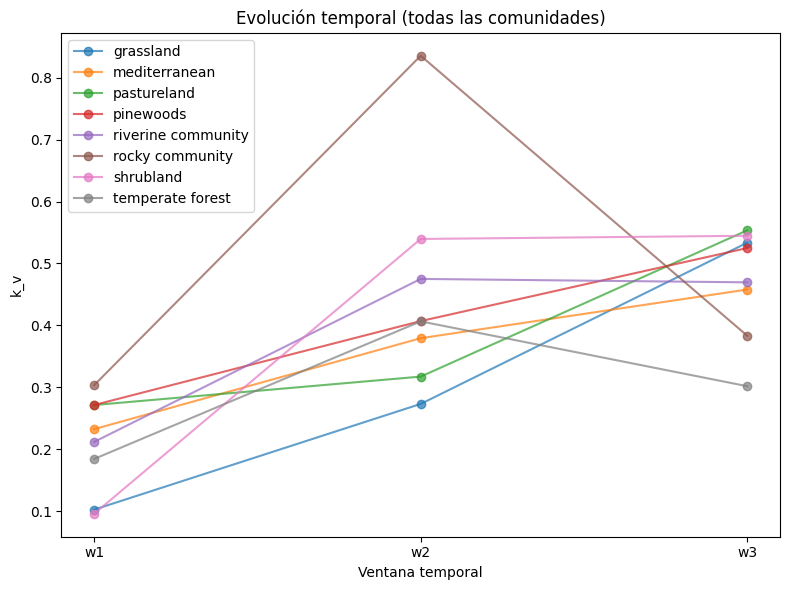

In [25]:
plt.figure(figsize=(8,6))

for sp in todas_comunidades:
    i = idx_global[sp]
    plt.plot([1,2,3], k_all[:, i], marker='o', alpha=0.7, label=sp)

plt.xlabel("Ventana temporal")
plt.ylabel("k_v")
plt.title("Evolución temporal (todas las comunidades)")
plt.legend()
plt.xticks([1,2,3], ["w1", "w2", "w3"])

plt.tight_layout()
plt.show()

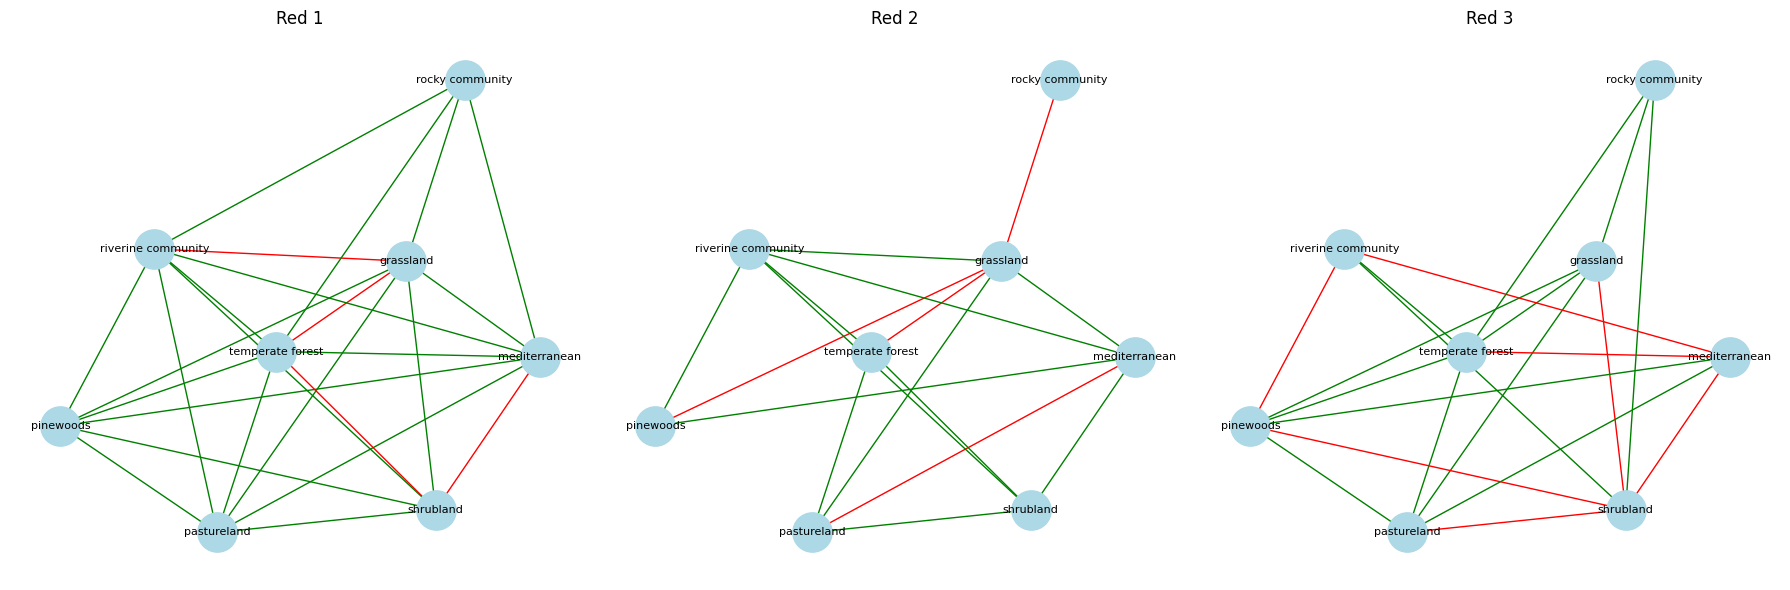

In [8]:
import matplotlib.pyplot as plt
import networkx as nx

# --- función para convertir A en grafo ---
def A_to_graph(A, comunidades):
    G = nx.Graph()
    
    for i, c in enumerate(comunidades):
        G.add_node(i, label=c)
    
    for i in range(len(A)):
        for j in range(i+1, len(A)):
            if A[i, j] != 0:
                G.add_edge(i, j, sign=A[i, j])
    
    return G

# --- construir grafos ---
grafos = []
labels_list = []

for data in datos:
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    A, comunidades = construir_A_comunidades(mat_sig, especies, species_to_community)
    
    G = A_to_graph(A, comunidades)
    grafos.append(G)
    labels_list.append({i: c for i, c in enumerate(comunidades)})

# --- layout común (IMPORTANTE para comparar) ---
# usamos el primer grafo como referencia
pos = nx.spring_layout(grafos[0], seed=42)

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ["Red 1", "Red 2", "Red 3"]

for k, ax in enumerate(axes):
    G = grafos[k]
    labels = labels_list[k]
    
    # colores de aristas según signo
    edge_colors = [
        "green" if G[u][v]["sign"] == 1 else "red"
        for u, v in G.edges()
    ]
    
    nx.draw(
        G, pos,
        ax=ax,
        with_labels=True,
        labels=labels,
        node_color="lightblue",
        edge_color=edge_colors,
        node_size=800,
        font_size=8
    )
    
    ax.set_title(titles[k])

plt.tight_layout()
plt.show()


In [10]:
def calcular_metricas_red(A):
    # solo parte superior (para no duplicar enlaces)
    upper = np.triu(A, k=1)
    
    enlaces_totales = np.count_nonzero(upper)
    enlaces_negativos = np.sum(upper == -1)
    
    if enlaces_totales == 0:
        porcentaje_neg = np.nan
    else:
        porcentaje_neg = 100 * enlaces_negativos / enlaces_totales
    
    return enlaces_totales, enlaces_negativos, porcentaje_neg


metricas = []

for t, data in enumerate(datos):
    especies = data["especies"]
    mat_sig = data["matriz_significancia"]
    
    A, comunidades = construir_A_comunidades(mat_sig, especies, species_to_community)
    
    enlaces_totales, enlaces_negativos, porcentaje_neg = calcular_metricas_red(A)
    
    metricas.append((enlaces_totales, enlaces_negativos, porcentaje_neg))


for i, (tot, neg, perc) in enumerate(metricas):
    print(f"Red {i+1}:")
    print(f"  Enlaces totales: {tot}")
    print(f"  Enlaces negativos: {neg}")
    print(f"  % negativos: {perc:.2f}%\n")

Red 1:
  Enlaces totales: 25
  Enlaces negativos: 4
  % negativos: 16.00%

Red 2:
  Enlaces totales: 16
  Enlaces negativos: 4
  % negativos: 25.00%

Red 3:
  Enlaces totales: 20
  Enlaces negativos: 7
  % negativos: 35.00%



In [19]:
balance_medio = []
balance_global = []


for t in range(k_all.shape[0]):
    SC_row = SC_all[t, :]
    k_row = k_all[t, :]
    
    # --- máscara válida ---
    mask = ~np.isnan(SC_row) & ~np.isnan(k_row)
    
    if np.sum(mask) == 0:
        balance_medio.append(np.nan)
        balance_global.append(np.nan)
        continue
    
    SC_valid = SC_row[mask]
    k_valid = k_row[mask]
    
    # --- balance medio ---
    bm = np.mean(k_valid)
    
    # --- balance global (ponderado) ---
    if np.sum(k_valid) == 0:
        bg = np.nan
    else:
        bg = np.sum(SC_valid * k_valid) / np.sum(SC_valid)
    
    balance_medio.append(bm)
    balance_global.append(bg)

In [20]:
for i in range(len(balance_medio)):
    print(f"Red {i+1}:")
    print(f"  Balance medio: {balance_medio[i]:.4f}")
    print(f"  Balance global: {balance_global[i]:.4f}\n")

Red 1:
  Balance medio: 0.2091
  Balance global: 0.2007

Red 2:
  Balance medio: 0.4542
  Balance global: 0.4043

Red 3:
  Balance medio: 0.4712
  Balance global: 0.4780



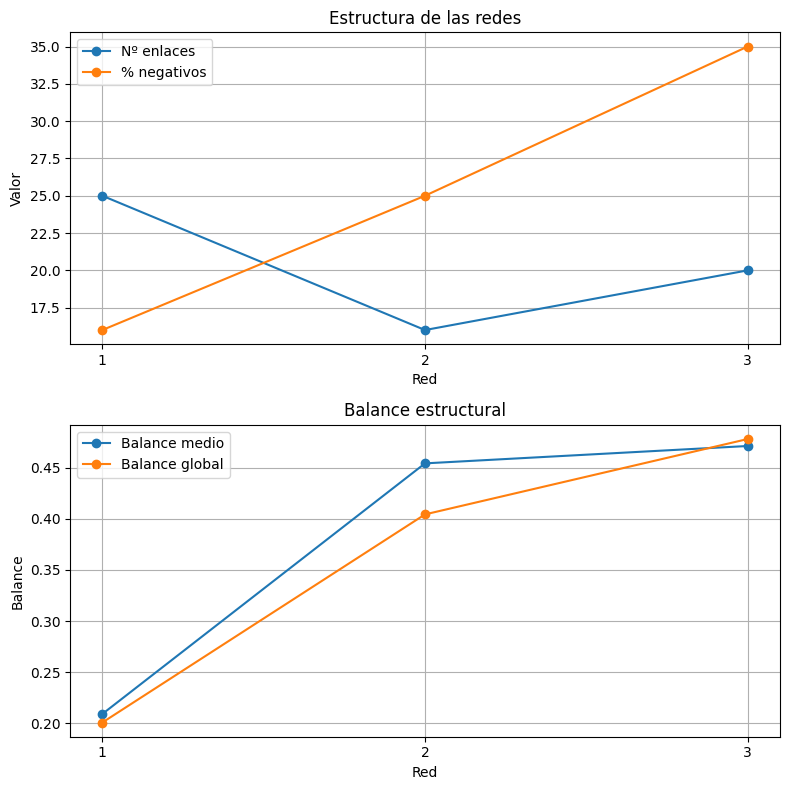

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# --- datos ---
x_redes = np.arange(1, k_all.shape[0] + 1)  # redes 1,2,3
x_temp = np.arange(2, k_all.shape[0] + 1)   # comparaciones (2-1, 3-2)

# temporalidades (asegúrate de tener estas listas)
# temporalidad (dir+signo)
# temporalidad_sin_signo (dir sin signo)
# temporalidad_no_dir (no dir sin signo)

# métricas de red
enlaces_tot = [m[0] for m in metricas]
enlaces_neg = [m[1] for m in metricas]
porc_neg = [m[2] for m in metricas]

# balances
bm = balance_medio
bg = balance_global

# --- figura ---
fig, axes = plt.subplots(2, 1, figsize=(8, 8))



# =========================
# 2. ESTRUCTURA DE RED
# =========================
ax = axes[0]

ax.plot(x_redes, enlaces_tot, marker='o', label='Nº enlaces')
ax.plot(x_redes, porc_neg, marker='o', label='% negativos')

ax.set_title("Estructura de las redes")
ax.set_xlabel("Red")
ax.set_ylabel("Valor")
ax.set_xticks(x_redes)
ax.legend()
ax.grid(True)


# =========================
# 3. BALANCE
# =========================
ax = axes[1]

ax.plot(x_redes, bm, marker='o', label='Balance medio')
ax.plot(x_redes, bg, marker='o', label='Balance global')

ax.set_title("Balance estructural")
ax.set_xlabel("Red")
ax.set_ylabel("Balance")
ax.set_xticks(x_redes)
ax.legend()
ax.grid(True)


plt.tight_layout()
plt.show()

# plots comparaciones

In [2]:
colors = plt.get_cmap("Set2").colors

w1 - wio: 211 links significativos
w1 - 0.5: 222 links significativos
w1 - 0.1: 227 links significativos
w2 - wio: 92 links significativos
w2 - 0.5: 127 links significativos
w2 - 0.1: 134 links significativos
w3 - wio: 111 links significativos
w3 - 0.5: 166 links significativos
w3 - 0.1: 163 links significativos


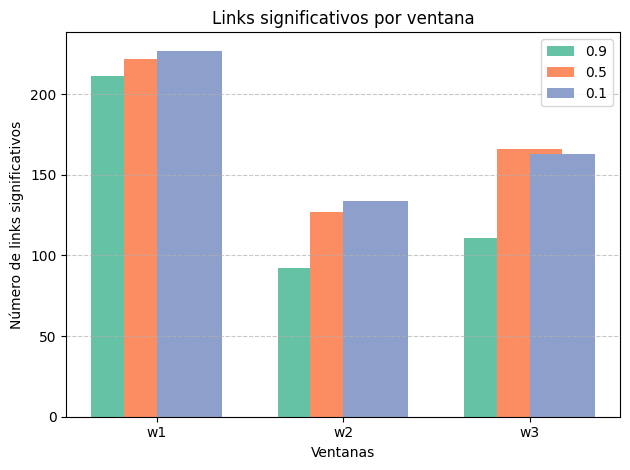

In [44]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

windows_names = ["w1", "w2", "w3"]
tipos = ["wio", "0.5", "0.1"]

# Diccionario para guardar resultados
resultados = {tipo: [] for tipo in tipos}

# Cargar datos y contar links significativos
for w in windows_names:
    for tipo in tipos:
        filename = f"results_{w}_{tipo}.pkl"
        with open(filename, "rb") as f:
            data = pickle.load(f)
        
        matriz_sig = np.array(data["matriz_significancia"])
        num_links = np.sum(matriz_sig != 0)
        
        resultados[tipo].append(num_links)
        print(f"{w} - {tipo}: {num_links} links significativos")

# Configuración de la gráfica
x = np.arange(len(windows_names))  # posiciones
width = 0.35  # ancho de las barras

fig, ax = plt.subplots()

# Barras
ax.bar(x - width/2, resultados["wio"], width, label="0.9", color=colors[0])
ax.bar(x , resultados["0.5"], width, label="0.5", color=colors[1])
ax.bar(x + width/2, resultados["0.1"], width, label="0.1", color=colors[2])

# Etiquetas
ax.set_xlabel("Ventanas")
ax.set_ylabel("Número de links significativos")
ax.set_title("Links significativos por ventana")
ax.set_xticks(x)
ax.set_xticklabels(windows_names)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

w1 - wio: 61 especies válidas
w1 - 0.5: 64 especies válidas
w1 - 0.1: 64 especies válidas
w2 - wio: 53 especies válidas
w2 - 0.5: 61 especies válidas
w2 - 0.1: 67 especies válidas
w3 - wio: 60 especies válidas
w3 - 0.5: 71 especies válidas
w3 - 0.1: 74 especies válidas


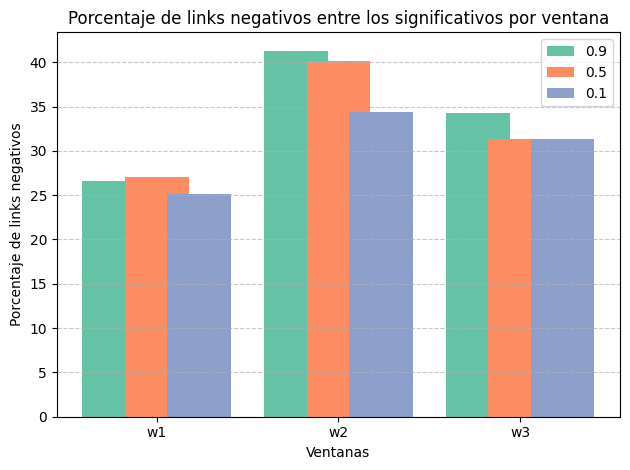

In [42]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

windows_names = ["w1", "w2", "w3"]
tipos = ["wio", "0.5", "0.1"]

# Diccionario para guardar resultados
resultados = {tipo: [] for tipo in tipos}

# Cargar datos y contar links significativos
for w in windows_names:
    for tipo in tipos:
        filename = f"results_{w}_{tipo}.pkl"
        with open(filename, "rb") as f:
            data = pickle.load(f)
        
        matriz_sig = np.array(data["matriz_significancia"])
        num_links = np.sum(matriz_sig !=0)
        matriz_coefs = np.array(data["matriz_coeficientes"])
        coefs_negativos = 0
        for i in range(matriz_sig.shape[0]):
            for j in range(matriz_sig.shape[1]):
                if matriz_sig[i, j] == -1:
                    if matriz_coefs[i, j] < 0.0:
                        coefs_negativos= coefs_negativos + 1
        #print(f"{w} - {tipo}: {coefs_negativos} coeficientes negativos de {num_links} links significativos")
        print(f"{w} - {tipo}: {len(np.array(data['especies']))} especies válidas")
        porcentaje_negativos = coefs_negativos / num_links * 100
        
        resultados[tipo].append(porcentaje_negativos)

# Configuración de la gráfica
x = np.arange(len(windows_names))  # posiciones
width = 0.35  # ancho de las barras

fig, ax = plt.subplots()

# Barras
ax.bar(x - 2*width/3, resultados["wio"], width, label="0.9", color=colors[0])
ax.bar(x , resultados["0.5"], width, label="0.5", color=colors[1])
ax.bar(x + 2*width/3, resultados["0.1"], width, label="0.1", color=colors[2])

# Etiquetas
ax.set_xlabel("Ventanas")
ax.set_ylabel("Porcentaje de links negativos")
ax.set_title("Porcentaje de links negativos entre los significativos por ventana")
ax.set_xticks(x)
ax.set_xticklabels(windows_names)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

w1 - wio: 61 especies válidas
w1 - int: 61 especies válidas
w1 - pc: 61 especies válidas
w2 - wio: 53 especies válidas
w2 - int: 49 especies válidas
w2 - pc: 53 especies válidas
w3 - wio: 60 especies válidas
w3 - int: 60 especies válidas
w3 - pc: 60 especies válidas


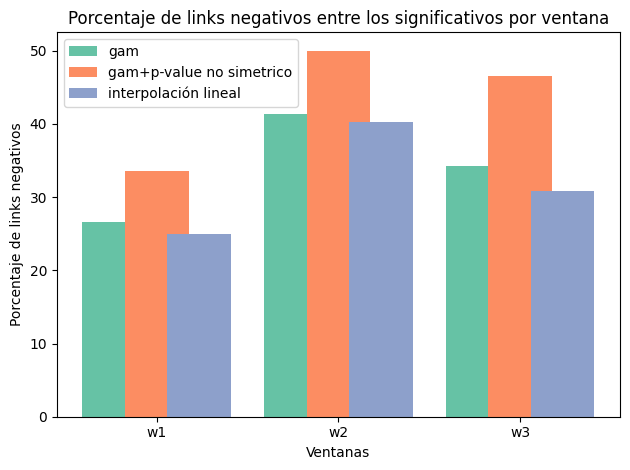

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

windows_names = ["w1", "w2", "w3"]
tipos = ["wio", "int", "pc"]

# Diccionario para guardar resultados
resultados = {tipo: [] for tipo in tipos}

# Cargar datos y contar links significativos
for w in windows_names:
    for tipo in tipos:
        filename = f"results_{w}_{tipo}.pkl"
        with open(filename, "rb") as f:
            data = pickle.load(f)
        
        matriz_sig = np.array(data["matriz_significancia"])
        num_links = np.sum(matriz_sig !=0)
        matriz_coefs = np.array(data["matriz_coeficientes"])
        coefs_negativos = 0
        for i in range(matriz_sig.shape[0]):
            for j in range(matriz_sig.shape[1]):
                if matriz_sig[i, j] == -1:
                    if matriz_coefs[i, j] < 0.0:
                        coefs_negativos= coefs_negativos + 1
        #print(f"{w} - {tipo}: {coefs_negativos} coeficientes negativos de {num_links} links significativos")
        print(f"{w} - {tipo}: {len(np.array(data['especies']))} especies válidas")
        porcentaje_negativos = coefs_negativos / num_links * 100
        
        resultados[tipo].append(porcentaje_negativos)
        #resultados[tipo].append(num_links)

# Configuración de la gráfica
x = np.arange(len(windows_names))  # posiciones
width = 0.35  # ancho de las barras

fig, ax = plt.subplots()

# Barras
ax.bar(x - 2*width/3, resultados["wio"], width, label="gam", color=colors[0])
ax.bar(x , resultados["pc"], width, label="gam+p-value no simetrico", color=colors[1])
ax.bar(x + 2*width/3, resultados["int"], width, label="interpolación lineal", color=colors[2])

# Etiquetas
ax.set_xlabel("Ventanas")
ax.set_ylabel("Porcentaje de links negativos")
ax.set_title("Porcentaje de links negativos entre los significativos por ventana")
ax.set_xticks(x)
ax.set_xticklabels(windows_names)
ax.legend()

plt.tight_layout()
plt.show()

w1 - wio: 61 especies válidas
w1 - int: 61 especies válidas
w1 - pc: 61 especies válidas
w2 - wio: 53 especies válidas
w2 - int: 49 especies válidas
w2 - pc: 53 especies válidas
w3 - wio: 60 especies válidas
w3 - int: 60 especies válidas
w3 - pc: 60 especies válidas


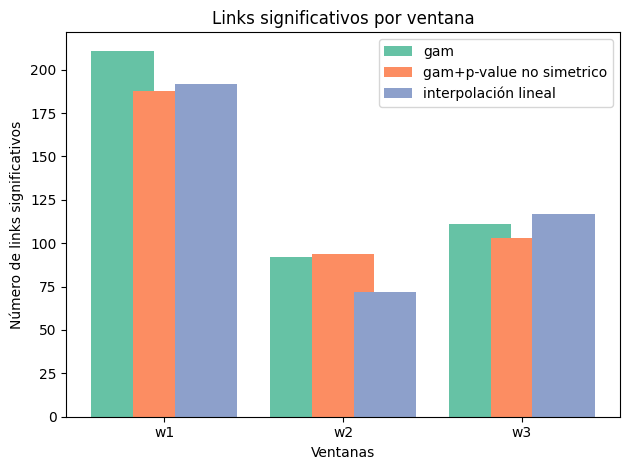

In [54]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

windows_names = ["w1", "w2", "w3"]
tipos = ["wio", "int", "pc"]

# Diccionario para guardar resultados
resultados = {tipo: [] for tipo in tipos}

# Cargar datos y contar links significativos
for w in windows_names:
    for tipo in tipos:
        filename = f"results_{w}_{tipo}.pkl"
        with open(filename, "rb") as f:
            data = pickle.load(f)
        
        matriz_sig = np.array(data["matriz_significancia"])
        num_links = np.sum(matriz_sig !=0)
        matriz_coefs = np.array(data["matriz_coeficientes"])
        coefs_negativos = 0
        for i in range(matriz_sig.shape[0]):
            for j in range(matriz_sig.shape[1]):
                if matriz_sig[i, j] == -1:
                    if matriz_coefs[i, j] < 0.0:
                        coefs_negativos= coefs_negativos + 1
        #print(f"{w} - {tipo}: {coefs_negativos} coeficientes negativos de {num_links} links significativos")
        print(f"{w} - {tipo}: {len(np.array(data['especies']))} especies válidas")
        porcentaje_negativos = coefs_negativos / num_links * 100
        
        #
        # resultados[tipo].append(porcentaje_negativos)
        resultados[tipo].append(num_links)

# Configuración de la gráfica
x = np.arange(len(windows_names))  # posiciones
width = 0.35  # ancho de las barras

fig, ax = plt.subplots()

# Barras
ax.bar(x - 2*width/3, resultados["wio"], width, label="gam", color=colors[0])
ax.bar(x , resultados["pc"], width, label="gam+p-value no simetrico", color=colors[1])
ax.bar(x + 2*width/3, resultados["int"], width, label="interpolación lineal", color=colors[2])

# Etiquetas
ax.set_xlabel("Ventanas")
ax.set_ylabel("Número de links significativos")
ax.set_title("Links significativos por ventana")
ax.set_xticks(x)
ax.set_xticklabels(windows_names)
ax.legend()

plt.tight_layout()
plt.show()

# PLOT COMUNIDADES

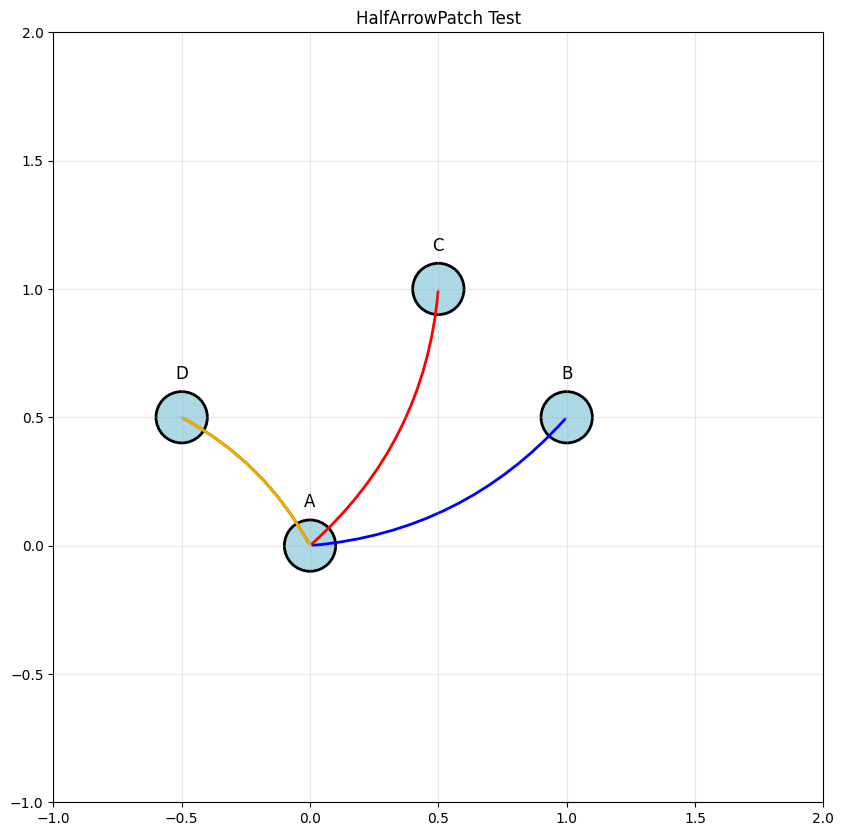

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from networkx.drawing.nx_pydot import pydot_layout
import matplotlib.colors as mcolors

from lib.halfarrowpatch import *

class HalfArrowPatch(FancyArrowPatch):
    """
    A custom arrow patch that draws arrows with half arrowheads.
    Useful for drawing multiple parallel edges between nodes.
    """
    
    def __init__(self, posA, posB, marker='-|>', width=1, height=1, 
                 color='black', linewidth=1, curvature=0.3, 
                 arrow_linewidth=2, **kwargs):
        """
        Initialize a HalfArrowPatch.
        
        Parameters:
        -----------
        posA, posB : tuples
            Starting and ending positions (x, y)
        marker : str
            Arrow style ('-|>' for right half, '|\\' for left half, etc.)
        width, height : float
            Width and height of the arrowhead
        color : str or tuple
            Arrow color
        linewidth : float
            Width of the arrow shaft
        curvature : float
            Curvature of the arrow (0 = straight, >0 = curved)
        arrow_linewidth : float
            Width of the arrowhead lines
        **kwargs : additional arguments for FancyArrowPatch
        """
        # Store parameters
        self.marker = marker
        self.arrow_width = width
        self.arrow_height = height
        self.arrow_linewidth = arrow_linewidth
        self.curvature = curvature
        
        # Initialize the parent class
        super().__init__(posA, posB, 
                        connectionstyle=f"arc3,rad={curvature}",
                        arrowstyle='-',  # Start with no arrowhead, we'll draw it manually
                        color=color,
                        linewidth=linewidth,
                        **kwargs)
        
        self._color = color
        self._posA = np.array(posA)
        self._posB = np.array(posB)
        
    def draw(self, renderer):
        """Override draw method to add custom half arrowhead."""
        # Draw the curved line first
        super().draw(renderer)
        
        # Get the transformed points
        trans = self.get_transform()
        posA_trans = trans.transform(self._posA)
        posB_trans = trans.transform(self._posB)
        
        # Calculate the direction at the end of the curve
        # For curved arrows, we need the tangent at the endpoint
        if self.curvature != 0:
            # For curved arrows, calculate tangent at endpoint
            C, R = self._get_circle_center()
            if C is not None:
                # Vector from center to endpoint
                v = posB_trans - C
                # Tangent is perpendicular to radius
                tangent = np.array([-v[1], v[0]])
                tangent = tangent / np.linalg.norm(tangent)
            else:
                # Fallback to straight line direction
                tangent = posB_trans - posA_trans
                tangent = tangent / np.linalg.norm(tangent)
        else:
            # Straight line - direction is from start to end
            tangent = posB_trans - posA_trans
            tangent = tangent / np.linalg.norm(tangent)
        
        # Perpendicular vector (90 degrees rotation)
        perp = np.array([-tangent[1], tangent[0]])
        
        # Calculate arrowhead points based on marker style
        arrowhead_center = posB_trans
        
        if self.marker == '-|>' or self.marker == '|>':
            # Right half arrowhead (pointing to the right of the direction)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        elif self.marker == '|\\' or self.marker == '<|':
            # Left half arrowhead (pointing to the left of the direction)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height - perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        elif self.marker == '|<':
            # Half arrowhead on the other side (for bidirectional)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        else:
            # Default full arrowhead
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height - perp * self.arrow_width/2,
                arrowhead_center
            ]
        
        # Create the arrowhead patch
        if len(points) >= 3:
            # Create path for the filled arrowhead
            verts = points
            codes = [Path.MOVETO] + [Path.LINETO] * (len(points)-2) + [Path.CLOSEPOLY]
            
            path = Path(verts, codes)
            patch = PathPatch(path, facecolor=self._color, 
                            edgecolor=self._color, 
                            linewidth=self.arrow_linewidth,
                            transform=transforms.IdentityTransform(),
                            zorder=self.zorder+1)
            
            # Draw the arrowhead
            patch.draw(renderer)
    
    def _get_circle_center(self):
        """Calculate the center of the circle for curved arrows."""
        try:
            A = self._posA
            B = self._posB
            rad = self.curvature
            
            # Calculate the center of the arc
            M = (A + B) / 2
            d = B - A
            L = np.linalg.norm(d)
            
            if L == 0:
                return None, None
                
            n = np.array([-d[1], d[0]]) / L
            h = rad * L / 2
            R = (L**2 / 4 + h**2) / (2 * h)
            C = M + n * (R - L**2 / (8 * h))
            
            return C, R
        except:
            return None, None


def test_half_arrow():
    """Test function to demonstrate HalfArrowPatch usage."""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Create some test positions
    pos = {
        'A': np.array([0, 0]),
        'B': np.array([1, 0.5]),
        'C': np.array([0.5, 1]),
        'D': np.array([-0.5, 0.5])
    }
    
    # Draw nodes
    for node, p in pos.items():
        circle = plt.Circle(p, 0.1, color='lightblue', ec='black', lw=2)
        ax.add_patch(circle)
        ax.text(p[0], p[1]+0.15, node, ha='center', fontsize=12)
    
    # Test different arrow styles
    # Right half arrow
    arrow1 = HalfArrowPatch(
        pos['A'], pos['B'],
        marker='-|>',
        width=0.2, height=0.3,
        color='blue',
        linewidth=2,
        curvature=0.2,
        arrow_linewidth=2
    )
    ax.add_patch(arrow1)
    
    # Left half arrow
    arrow2 = HalfArrowPatch(
        pos['A'], pos['C'],
        marker='|\\',
        width=0.2, height=0.3,
        color='red',
        linewidth=2,
        curvature=0.2,
        arrow_linewidth=2
    )
    ax.add_patch(arrow2)
    
    # Double arrows (parallel)
    arrow3 = HalfArrowPatch(
        pos['A'], pos['D'],
        marker='-|>',
        width=0.2, height=0.3,
        color='green',
        linewidth=2,
        curvature=0.15,
        arrow_linewidth=2
    )
    ax.add_patch(arrow3)
    
    arrow4 = HalfArrowPatch(
        pos['A'], pos['D'],
        marker='|\\',
        width=0.2, height=0.3,
        color='orange',
        linewidth=2,
        curvature=0.15,
        arrow_linewidth=2
    )
    # Adjust offset manually
    arrow4._posA = arrow4._posA + np.array([0.05, 0.05])
    arrow4._posB = arrow4._posB + np.array([0.05, 0.05])
    ax.add_patch(arrow4)
    
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title('HalfArrowPatch Test')
    
    plt.show()


if __name__ == "__main__":
    test_half_arrow()
    



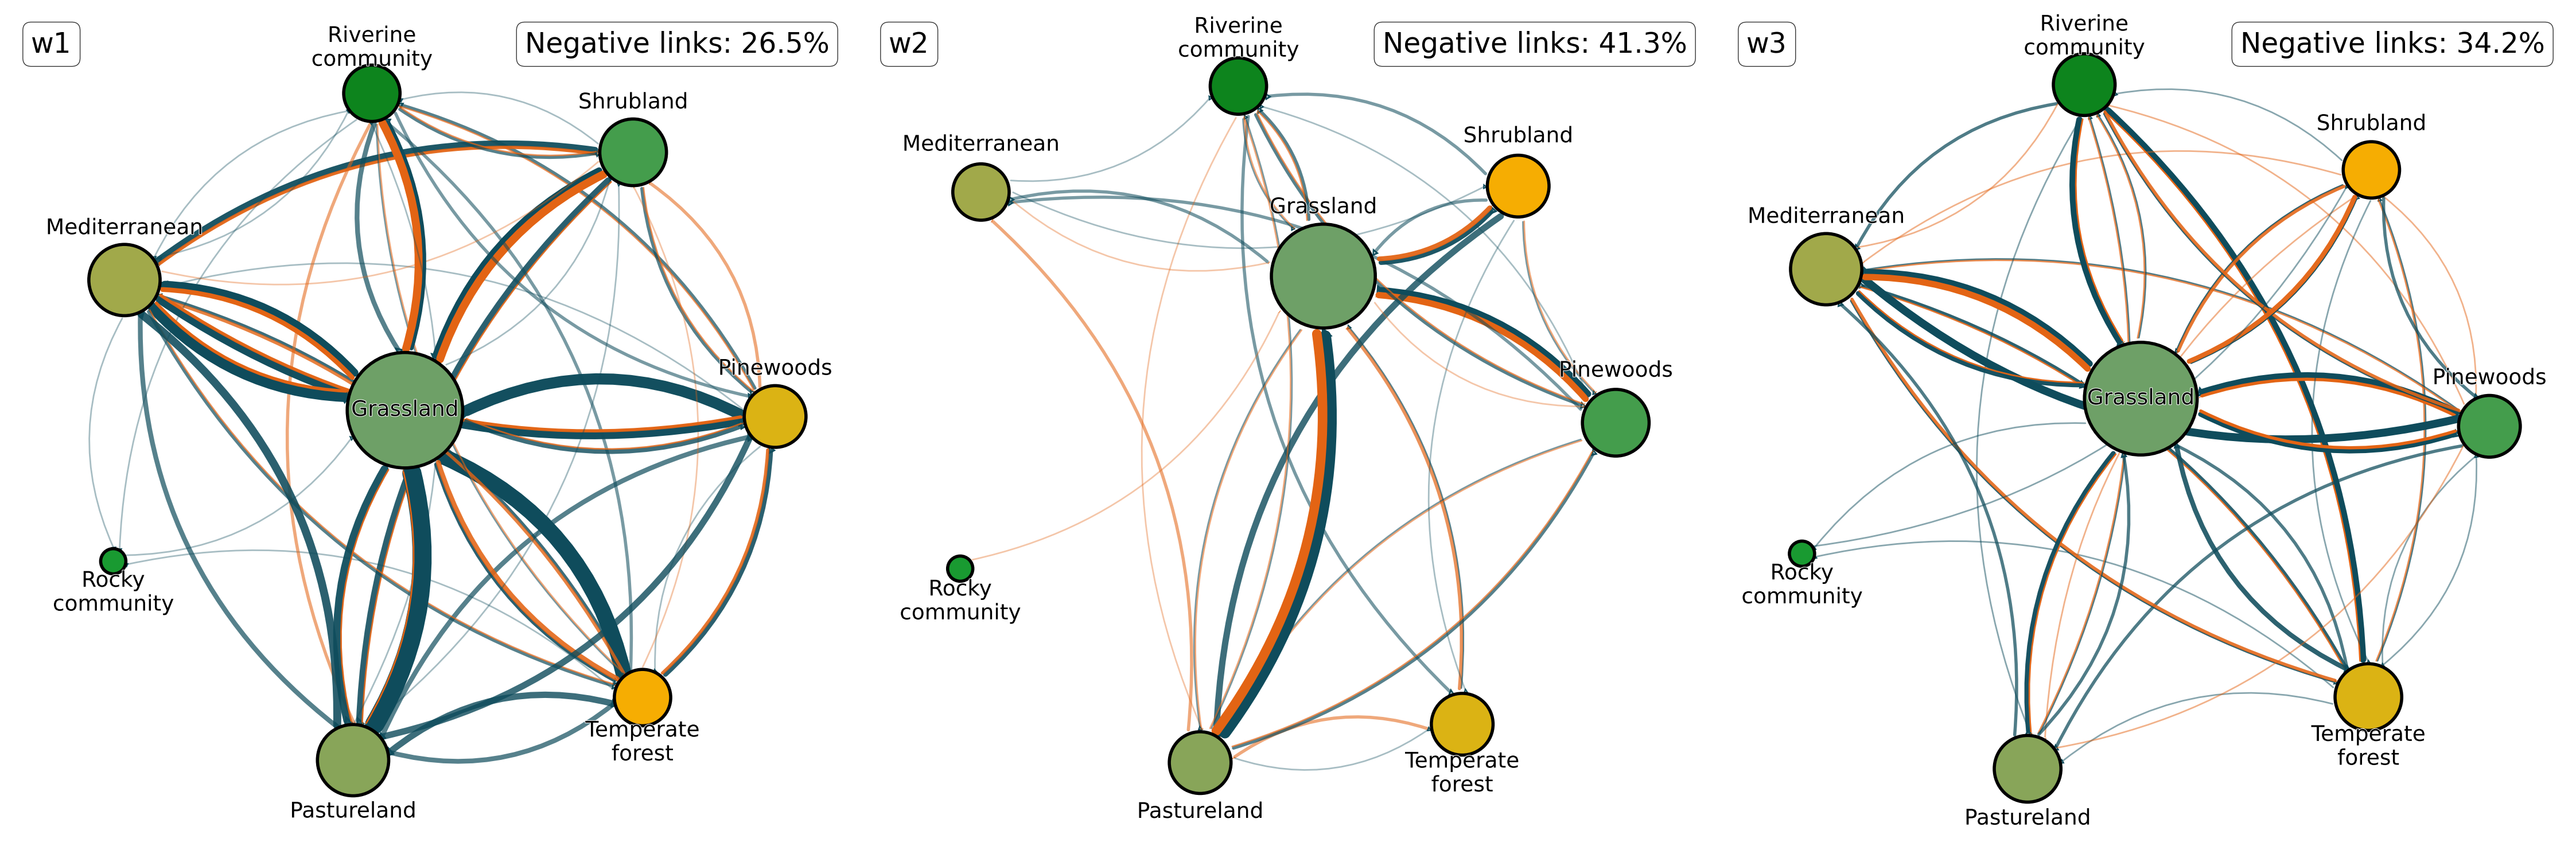

In [3]:
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors

# Importar las funciones personalizadas
from lib.halfarrowpatch import *  # Asegúrate de que esta importación funciona

# =====================================================
# FUNCIONES AUXILIARES (copiadas de tu código)
# =====================================================

def arc3_circle_center(posA, posB, rad):
    A, B = np.array(posA), np.array(posB)
    M = (A + B) / 2
    d = B - A
    L = np.linalg.norm(d)
    n = np.array([-d[1], d[0]]) / L
    h = rad * L / 2
    R = (L**2 / 4 + h**2) / (2 * h)
    C = M + n * (R - L**2 / (8 * h))
    return C, R

def rotate_point(p, center, angle):
    s, c = np.sin(angle), np.cos(angle)
    v = p - center
    return center + np.array([c*v[0] - s*v[1], s*v[0] + c*v[1]])

def add_curved_edge(ax, pos, u, v, color="black", weight=1.5, rad=0.3, angle=0, 
                    offset=0.0, node_radius_u=0.05, node_radius_v=0.05, 
                    arrowstyle='-|>', zorder=1, **kwargs):

    U = np.array(pos[u])
    V = np.array(pos[v])
    C, R = arc3_circle_center(np.array(pos[u]), np.array(pos[v]), rad)
    
    # Rotate endpoints
    U2 = rotate_point(U, C, np.deg2rad(angle))
    V2 = rotate_point(V, C, np.deg2rad(angle))

    x1, y1 = U2
    x2, y2 = V2

    # Compute direction and perpendicular vectors
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    dir_vec = np.array([dx, dy]) / dist
    perp = np.array([-dy, dx]) / dist

    # Apply offset (for parallel edges)
    posA = np.array([x1, y1]) + perp * offset + dir_vec * np.sqrt(node_radius_u)
    posB = np.array([x2, y2]) + perp * offset - dir_vec * np.sqrt(node_radius_v)

    arrow = HalfArrowPatch(
        posA=posA,
        posB=posB,
        marker=arrowstyle,
        width=1,
        height=1,
        color=color,
        linewidth=weight,
        curvature=rad,
        zorder=zorder,
        arrow_linewidth=2.5*np.sqrt(weight),
        **kwargs
    )

    ax.add_patch(arrow)

def sequential_custom_generator():
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d"] # greens and yellows
    index = 0
    # add randomness to which color we take each time (add a constant seed)
    np.random.seed(42)
    random_indices = np.random.permutation(len(colors_list))
    while True:
        yield mcolors.to_rgb(colors_list[random_indices[index] % len(colors_list)])
        index += 1

# =====================================================
# CONFIG
# =====================================================

windows_names = ["w1", "w2", "w3"]

POS_COLOR = "#0F4C5C"  # Azul verdoso para positivas
NEG_COLOR = "#E36414"  # Naranja para negativas

# =====================================================
# COMUNIDADES
# =====================================================

groups_df = pd.read_csv("basa_groups.csv")
species_to_community = dict(zip(groups_df["Taxa"], groups_df["Community"]))

# =====================================================
# MAPEO DE COMUNIDADES A ÍNDICES Y ETIQUETAS
# =====================================================

# Crear mapeo inverso de comunidad a índice numérico
community_to_index = {
    'grassland': 0,
    'mediterranean': 1,
    'pastureland': 2,
    'pinewoods': 3,
    'riverine community': 4,
    'rocky community': 5,
    'shrubland': 6,
    'temperate forest': 7
}

# Mapeo de índice a etiqueta (igual que en el original)
labels = {
    7: 'Temperate\nforest',
    3: 'Pinewoods',
    6: 'Shrubland',
    4: 'Riverine\ncommunity',
    1: 'Mediterranean',
    2: 'Pastureland',
    0: 'Grassland',
    5: 'Rocky\ncommunity'
}

# Orden para las posiciones iniciales (igual que en el original)
order = {
    'Temperate\nforest': 1,
    'Pinewoods': 2,
    'Shrubland': 3,
    'Riverine\ncommunity': 4,
    'Mediterranean': 5,
    'Rocky\ncommunity': 6,
    'Pastureland': 7
}

# Mapeo inverso de comunidad a etiqueta
community_to_label = {
    'temperate forest': 'Temperate\nforest',
    'pinewoods': 'Pinewoods',
    'shrubland': 'Shrubland',
    'riverine community': 'Riverine\ncommunity',
    'mediterranean': 'Mediterranean',
    'rocky community': 'Rocky\ncommunity',
    'pastureland': 'Pastureland',
    'grassland': 'Grassland'
}

# =====================================================
# FIGURA
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(45, 15))

for idx, window_name in enumerate(windows_names):
    ax = axes[idx]

    with open(f"results_{window_name}_wio.pkl", "rb") as f:
        data = pickle.load(f)

    sig = np.array(data["matriz_significancia"])
    species_order = data["especies"]

    # =================================================
    # RED ESPECIES
    # =================================================

    G_species = nx.DiGraph()

    for sp in species_order:
        if sp in species_to_community:
            G_species.add_node(sp,
                community=species_to_community[sp])

    n = len(species_order)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            sp1 = species_order[i]
            sp2 = species_order[j]

            if sp1 not in species_to_community or sp2 not in species_to_community:
                continue

            sign = sig[i, j]

            if sign == 0:
                continue

            G_species.add_edge(sp1, sp2, sign=sign)

    # =================================================
    # CONTAR ESPECIES POR COMUNIDAD
    # =================================================

    community_counts = defaultdict(int)

    for node in G_species.nodes():
        comm = G_species.nodes[node]["community"]
        community_counts[comm] += 1

    # =================================================
    # RED COMUNIDADES
    # =================================================

    G = nx.MultiDiGraph()

    for comm, count in community_counts.items():
        G.add_node(comm, size=count)

    # Contar edges positivos y negativos entre comunidades
    edge_counts = defaultdict(lambda: {"pos": 0, "neg": 0})

    for u, v, data in G_species.edges(data=True):
        cu = G_species.nodes[u]["community"]
        cv = G_species.nodes[v]["community"]

        if cu == cv:
            continue

        if data["sign"] == 1:
            edge_counts[(cu, cv)]["pos"] += 1
        else:
            edge_counts[(cu, cv)]["neg"] += 1

    # Añadir edges a la red de comunidades
    for (u, v), counts in edge_counts.items():
        if counts["pos"] > 0:
            G.add_edge(u, v, color=POS_COLOR, weight=counts["pos"] * 2)
        if counts["neg"] > 0:
            G.add_edge(u, v, color=NEG_COLOR, weight=counts["neg"] * 2)

    # Eliminar edges con peso cero (por si acaso)
    for u, v, key, weight in G.copy().edges(data="weight", keys=True):
        if weight == 0:
            G.remove_edge(u, v, key)

    # =================================================
    # POSICIONES INICIALES (como en el original)
    # =================================================

    # Obtener lista de comunidades presentes
    communities_present = list(G.nodes())
    
    # Configurar posiciones iniciales
    initial_pos = {}
    
    # Grassland en el centro (índice 0)
    grassland_comm = None
    for comm in communities_present:
        if community_to_index[comm] == 0:
            grassland_comm = comm
            initial_pos[comm] = np.array([0.0, 0.0])
            break

    # Calcular posiciones para las demás comunidades
    if grassland_comm:
        N = len(communities_present)
        angle_step = 2 * np.pi / (N - 1)
        other_comms = [c for c in communities_present if c != grassland_comm]
        
        for comm in other_comms:
            idx = community_to_index[comm]
            label = labels[idx]
            # Asegurarse de que la etiqueta existe en order
            if label in order:
                angle = angle_step * (order[label] - 2)
                initial_pos[comm] = np.array([np.cos(angle), np.sin(angle)])
            else:
                # Si no está en el orden, asignar posición aleatoria en el círculo
                angle = np.random.uniform(0, 2*np.pi)
                initial_pos[comm] = np.array([np.cos(angle), np.sin(angle)])

    # Aplicar spring layout con posiciones iniciales
    pos = nx.spring_layout(
        G,
        weight='weight',
        seed=1,
        pos=initial_pos,
        iterations=2
    )

    # =================================================
    # NODOS
    # =================================================

    node_sizes = {n: G.nodes[n]['size'] * 1000 for n in G.nodes()}
    
    # Generar colores para las comunidades
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1 / 700000
    scale = 0.00094  # escala para offsets

    # =================================================
    # ARISTAS (usando HalfArrowPatch)
    # =================================================

    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(
        sum(edge['weight'] for edge in edges)
        for edges in edge_groups.values()
    ) if edge_groups else 1

    # Dibujar aristas agrupadas por par de nodos
    for (u, v), edges in edge_groups.items():
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4 * total_width / max_total_weight), 1)

        if n == 1:
            # Una sola arista
            data = edges[0]
            # Usar arrowstyle según el color
            if data["color"] == POS_COLOR:
                arrow_style = '|/'  # Para positivas
            else:
                arrow_style = '|\\'  # Para negativas
            
            add_curved_edge(
                ax, pos, u, v,
                color=data["color"],
                weight=data["weight"],
                rad=0.25,
                angle=0,
                offset=0.0,
                node_radius_u=node_sizes[u] * node_size_scale,
                node_radius_v=node_sizes[v] * node_size_scale,
                arrowstyle=arrow_style,
                zorder=-1,
                alpha=alpha
            )

        elif n == 2:
            # Dos aristas: una positiva y una negativa
            # Separar por color para identificar positiva y negativa
            pos_edges = [e for e in edges if e["color"] == POS_COLOR]
            neg_edges = [e for e in edges if e["color"] == NEG_COLOR]
            
            sorted_edges = []
            if pos_edges:
                sorted_edges.append(pos_edges[0])
            if neg_edges:
                sorted_edges.append(neg_edges[0])
            
            if len(sorted_edges) == 2:
                w_0 = sorted_edges[0]["weight"]
                w_1 = sorted_edges[1]["weight"]
                
                # Calcular offsets para que queden paralelas
                offset = (w_0 + w_1 / 1.0) * scale
                
                np.random.seed(0)
                rad = np.random.uniform(0.15, 0.25)
                
                # Primera arista (normalmente la positiva)
                add_curved_edge(
                    ax, pos, u, v,
                    color=sorted_edges[0]["color"],
                    weight=w_0,
                    rad=rad,
                    angle=0,
                    offset=-offset - 0.02,
                    node_radius_u=node_sizes[u] * node_size_scale,
                    node_radius_v=node_sizes[v] * node_size_scale,
                    arrowstyle='|/',  # Para la primera
                    zorder=-1,
                    alpha=alpha
                )
                
                # Segunda arista (normalmente la negativa)
                add_curved_edge(
                    ax, pos, u, v,
                    color=sorted_edges[1]["color"],
                    weight=w_1,
                    rad=rad,
                    angle=0,
                    offset=-0.02,
                    node_radius_u=node_sizes[u] * node_size_scale,
                    node_radius_v=node_sizes[v] * node_size_scale,
                    arrowstyle='|\\',  # Para la segunda
                    zorder=-1,
                    alpha=alpha
                )
            else:
                # Si por alguna razón solo hay un tipo de edge, dibujar como caso n=1
                for data in edges:
                    arrow_style = '|/' if data["color"] == POS_COLOR else '|\\'
                    add_curved_edge(
                        ax, pos, u, v,
                        color=data["color"],
                        weight=data["weight"],
                        rad=0.25,
                        angle=0,
                        offset=0.0,
                        node_radius_u=node_sizes[u] * node_size_scale,
                        node_radius_v=node_sizes[v] * node_size_scale,
                        arrowstyle=arrow_style,
                        zorder=-1,
                        alpha=alpha
                    )

    # =================================================
    # DIBUJAR NODOS
    # =================================================

    nx.draw_networkx_nodes(
        G, pos,
        node_color=[community_colors[node] for node in G.nodes()],
        ax=ax,
        node_size=[node_sizes[n] for n in G.nodes()],
        edgecolors="black",
        linewidths=4
    )

    # =================================================
    # ETIQUETAS CON OFFSET (como en el original)
    # =================================================

    label_pos = {}
    for n in G.nodes():
        # Calcular offset para la etiqueta
        if pos[n][1] > 0.1:
            offset = np.array([0, np.sqrt(node_sizes[n]) * 0.001 + 0.06])
        elif pos[n][1] < -0.1:
            offset = np.array([0, -np.sqrt(node_sizes[n]) * 0.001 - 0.06])
        elif pos[n][0] > 0.2:
            offset = np.array([0, np.sqrt(node_sizes[n]) * 0.001 + 0.06])
        else:
            offset = np.array([0, 0.0])
            
        label_pos[n] = pos[n] + offset

    # Crear diccionario de etiquetas
    node_labels = {}
    for n in G.nodes():
        idx = community_to_index[n]
        node_labels[n] = labels[idx]

    texts = nx.draw_networkx_labels(
        G, label_pos,
        ax=ax,
        labels=node_labels,
        font_size=27,
        font_color='black'
    )

    for text in texts.values():
        text.set_path_effects([
            path_effects.Stroke(linewidth=1.5, foreground='white'),
            path_effects.Normal()
        ])

    # =================================================
    # AJUSTAR LÍMITES DEL GRÁFICO
    # =================================================

    # Hacer el gráfico cuadrado
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    width = xlim[1] - xlim[0]
    height = ylim[1] - ylim[0]
    
    if width > height:
        center_y = (ylim[0] + ylim[1]) / 2
        ax.set_ylim(center_y - width/2, center_y + width/2)
    else:
        center_x = (xlim[0] + xlim[1]) / 2
        ax.set_xlim(center_x - height/2, center_x + height/2)
    
    # Añadir margen
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)

    # =================================================
    # TEXTO INFORMATIVO
    # =================================================

    # Calcular porcentaje de links negativos (para la red de especies)
    negative_links = len([e for e in G_species.edges(data=True) if e[2]['sign'] < 0])
    total_links = G_species.number_of_edges()
    negative_percentage = negative_links / total_links if total_links > 0 else 0

    # Añadir título con el nombre de la ventana temporal
    ax.text(0.03, 0.97, window_name,
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Añadir porcentaje de links negativos
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.axis("off")

plt.tight_layout()
plt.show()

# PLOT UMBRAL P VALOR

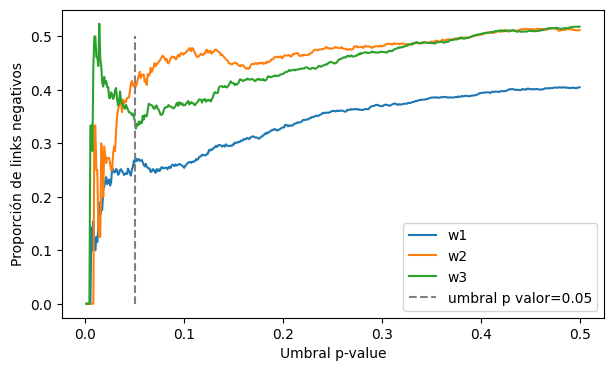

In [23]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# =====================================================
# ARCHIVOS
# =====================================================

files = {
    "w1": "results_w1_wio.pkl",
    "w2": "results_w2_wio.pkl",
    "w3": "results_w3_wio.pkl"
}

# =====================================================
# RANGO DE P-VALORES
# =====================================================

p_thresholds = np.linspace(0.001, 0.5, 500)

# =====================================================
# FUNCIÓN
# =====================================================

def porcentaje_negativos(matriz_coef, matriz_pval, matriz_sig, p_th):

    n = matriz_coef.shape[0]
    
    total = 0
    negativos = 0

    for i in range(n):
        for j in range(n):

            if i == j:
                continue

            if (matriz_pval[i, j] < p_th):
                total += 1

                if matriz_coef[i, j] < 0:
                    negativos += 1

    if total == 0:
        return 0

    return negativos / total


# =====================================================
# CÁLCULO
# =====================================================

resultados = {}

for key, file in files.items():

    with open(file, "rb") as f:
        res = pickle.load(f)

    matriz_coef = res["matriz_coeficientes"]
    matriz_pval = res["matriz_pvalores"]
    matriz_sig= res["matriz_significancia"]

    porcentajes = []

    for p_th in p_thresholds:
        perc = porcentaje_negativos(matriz_coef, matriz_pval, matriz_sig, p_th)
        porcentajes.append(perc)

    resultados[key] = porcentajes


# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(7,4))

for key in resultados:
    plt.plot(p_thresholds, resultados[key], label=key)
plt.vlines(0.05,0,0.5, 'grey', "--", label="umbral p valor=0.05")
plt.xlabel("Umbral p-value")
plt.ylabel("Proporción de links negativos")
#plt.title("Evolución de links negativos significativos")
plt.legend()

plt.show()

# PLOTS DISTRIBUCIÓN P VALORES, COEFICIENTES...

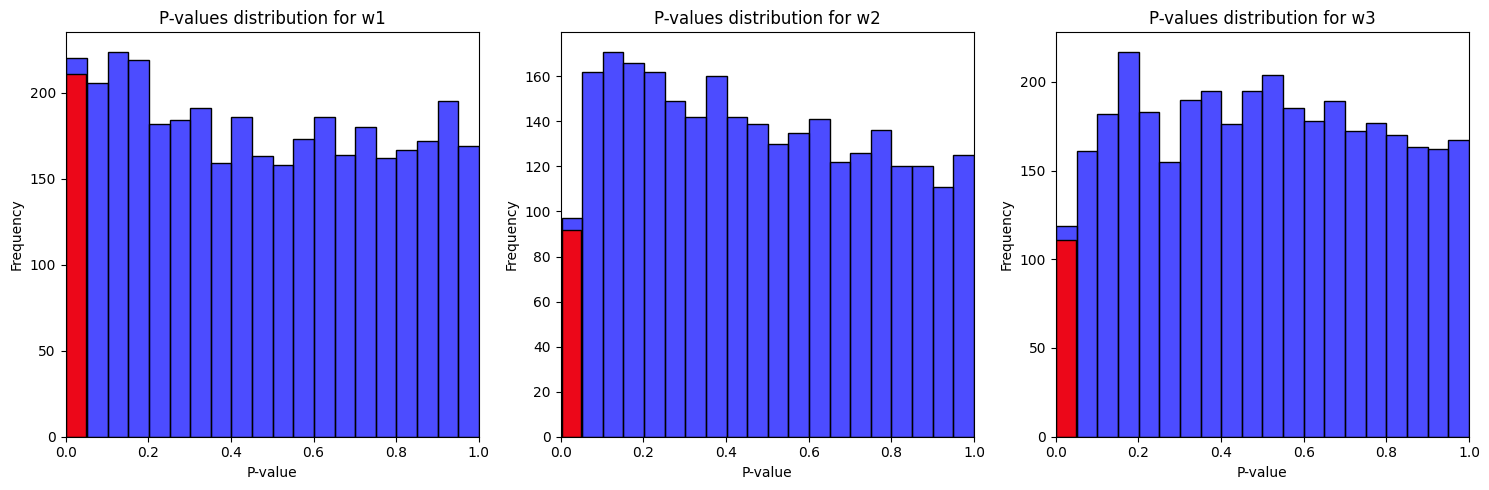

In [30]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, window_name in enumerate(windows_names):
    with open(f"results_{window_name}_wio.pkl", "rb") as f:
        data = pickle.load(f)

    p_values = np.array(data["matriz_pvalores"])
    p_values = p_values.flatten()
    p_values = p_values[~np.isnan(p_values)]

    # sns.histplot(p_values, bins=50, ax=axes[idx], )
    # sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
    sns.histplot(p_values, binwidth=0.05, ax=axes[idx], color='blue', alpha=0.7, stat='count')
    sns.histplot(p_values[p_values < 0.05], binwidth=0.05, ax=axes[idx], color='red', alpha=0.9, stat='count')
    axes[idx].set_title(f'P-values distribution for {window_name}')
    axes[idx].set_xlabel('P-value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()


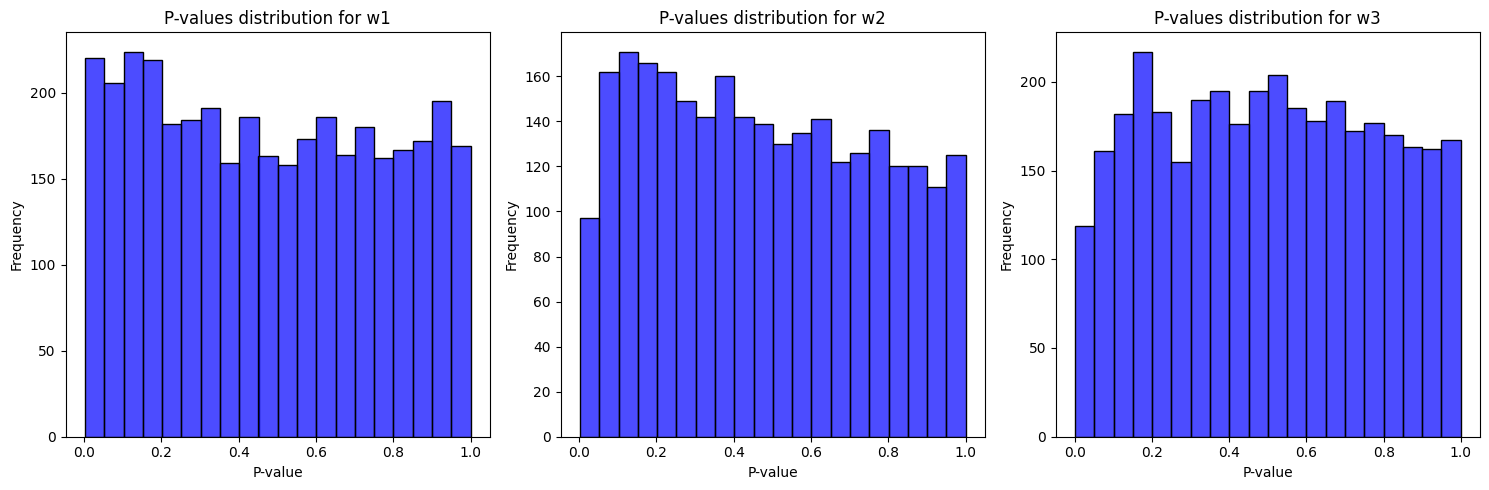

In [24]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
import seaborn as sns
windows_names=["w1", "w2", "w3"]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, window_name in enumerate(windows_names):
    with open(f"results_{window_name}_wio.pkl", "rb") as f:
        data = pickle.load(f)

    p_values = np.array(data["matriz_pvalores"])
    p_values = p_values.flatten()
    p_values = p_values[~np.isnan(p_values)]

    # sns.histplot(p_values, bins=50, ax=axes[idx], )
    # sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
    sns.histplot(p_values, binwidth=0.05, ax=axes[idx], color='blue', alpha=0.7, stat='count')
    #sns.histplot(p_values[p_values < 0.05], binwidth=0.025, ax=axes[idx], color='red', alpha=0.9, stat='count')
    axes[idx].set_title(f'P-values distribution for {window_name}')
    axes[idx].set_xlabel('P-value')
    axes[idx].set_ylabel('Frequency')
    #axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()


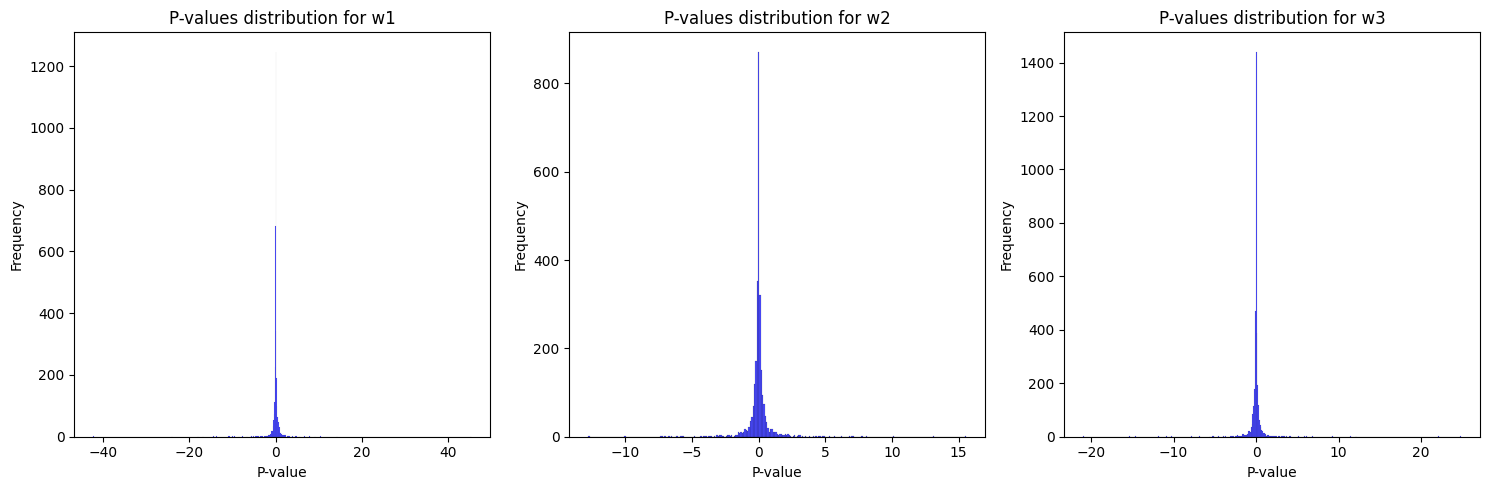

In [33]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
import seaborn as sns
windows_names=["w1", "w2", "w3"]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, window_name in enumerate(windows_names):
    with open(f"results_{window_name}_wio.pkl", "rb") as f:
        data = pickle.load(f)

    p_values = np.array(data["matriz_coeficientes"])
    p_values = p_values.flatten()
    p_values = p_values[~np.isnan(p_values)]

    # sns.histplot(p_values, bins=50, ax=axes[idx], )
    # sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
    sns.histplot(p_values, binwidth=0.1, ax=axes[idx], color='blue', alpha=0.7, stat='count')
    #sns.histplot(p_values[p_values < 0.05], binwidth=0.025, ax=axes[idx], color='red', alpha=0.9, stat='count')
    axes[idx].set_title(f'P-values distribution for {window_name}')
    axes[idx].set_xlabel('P-value')
    axes[idx].set_ylabel('Frequency')
    #axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()


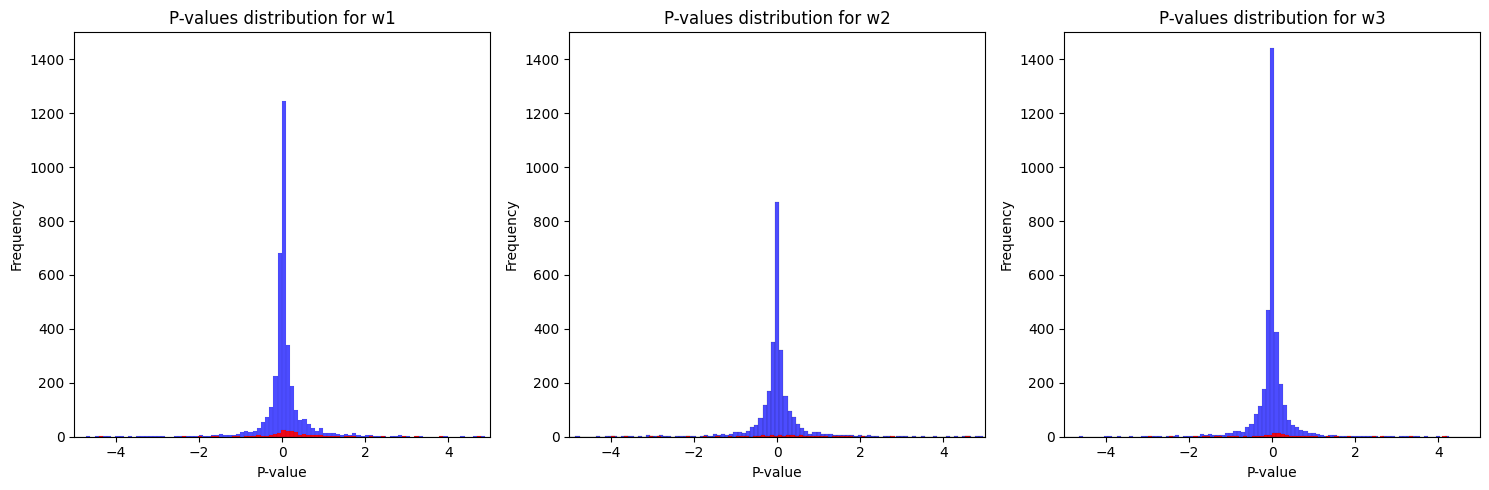

In [41]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
import seaborn as sns
windows_names=["w1", "w2", "w3"]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, window_name in enumerate(windows_names):
    with open(f"results_{window_name}_wio.pkl", "rb") as f:
        data = pickle.load(f)

    p_values = np.array(data["matriz_coeficientes"])
    p_values = p_values.flatten()
    
    sig_values = np.array(data["matriz_significancia"])
    sig_values = sig_values.flatten()
    sig_values = sig_values[~np.isnan(sig_values)]

    sig_coeficients = p_values[sig_values != 0]
    p_values = p_values[~np.isnan(p_values)]
    
    sns.histplot(p_values, binwidth=0.1, ax=axes[idx], color='blue', alpha=0.7, stat='count')
    sns.histplot(sig_coeficients, binwidth=0.1, ax=axes[idx], color='red', alpha=0.9, stat='count')
    axes[idx].set_title(f'P-values distribution for {window_name}')
    axes[idx].set_xlabel('P-value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_xlim(-5,5)
    axes[idx].set_ylim(0, 1500)

plt.tight_layout()
plt.show()


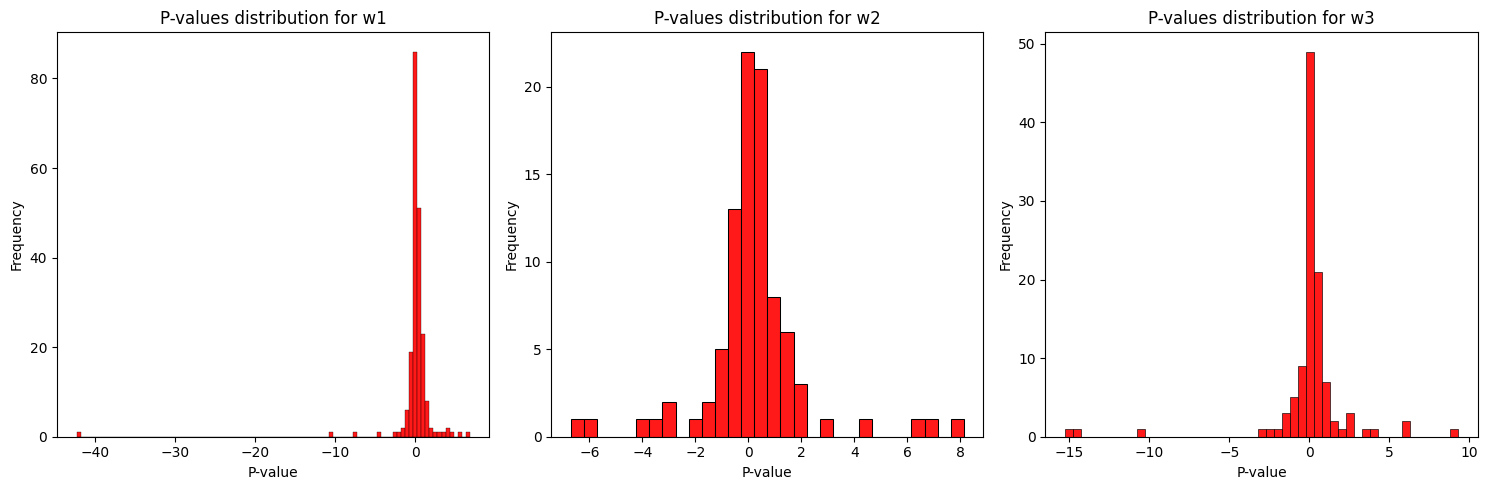

In [37]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
import seaborn as sns
windows_names=["w1", "w2", "w3"]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, window_name in enumerate(windows_names):
    with open(f"results_{window_name}_wio.pkl", "rb") as f:
        data = pickle.load(f)

    p_values = np.array(data["matriz_coeficientes"])
    p_values = p_values.flatten()
    
    sig_values = np.array(data["matriz_significancia"])
    sig_values = sig_values.flatten()
    sig_values = sig_values[~np.isnan(sig_values)]

    sig_coeficients = p_values[sig_values != 0]
    p_values = p_values[~np.isnan(p_values)]
    
    #sns.histplot(p_values, binwidth=0.1, ax=axes[idx], color='blue', alpha=0.7, stat='count')
    sns.histplot(sig_coeficients, binwidth=0.5, ax=axes[idx], color='red', alpha=0.9, stat='count')
    axes[idx].set_title(f'P-values distribution for {window_name}')
    axes[idx].set_xlabel('P-value')
    axes[idx].set_ylabel('Frequency')
    #axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()
